# NASA Turbine Data Analysis

**Question**: "How accurately can Remaining Useful Life be predicted for a turbofan engine using its recent sensor readings, and which sensors contribute most to that prediction?"

**Background:**: 
C-MAPSS stands for Commercial Modular Aero-Propulsion System Simulation. These jet engines are capable of producing 90,000 lbs of thrust. It is simulation data by NASA of turbofan jet engines. Predictive maintenance is crucial to preventing catastrophic failures and high costs, and detecting degradation is an important part of that process. 

**Hypothesis:**
RUL can be predicted from sensor data with moderate accuracy that varies depending on how close the engine is to failure–most likely more accurate for engines where the degradation signal is more pronounced later in life and less accurate earlier in the engine's life. Models capable of using sequential information such as CNNs and LSTMs will outperform models relying on single time-stamp readings (Multiple Linear regression, XGBoost, and Random Forest), since degradation manifests over time. A subset of sensors will contribute disproportionately to the model's predictive accuracy while others will contribute little.

In [1]:
#import packages and retrieve data
import pandas as pd
from pathlib import Path
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import tensorflow as tf
import numpy as np
import xgboost as xgb

DATA_DIR = Path(".")
DATASET = "FD001"

COLS = (
    ["unit_number", "time_cycles"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

In [2]:
#creating the training and test dataframes
train = pd.read_csv(DATA_DIR / f"train_{DATASET}.txt", sep=r"\s+", header=None, names=COLS)
test = pd.read_csv(DATA_DIR / f"test_{DATASET}.txt", sep=r"\s+", header=None, names=COLS)
rul = pd.read_csv(DATA_DIR / f"RUL_{DATASET}.txt", sep=r"\s+", header=None, names=["RUL"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (20631, 26)
Test shape: (13096, 26)


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Data Preprocessing and Cleaning

The dataset is called is called the NASA CMAPSS (Commercial Modular Aero-Propulsion System Simulation) Jet Engine dataset. It is a synthesized dataset containing 26 columns. 21 of those are corresponding to sensor data during one cycle. The sensors are numbered, however the measurements that the sensors correspond to have not specifically been given. There are 3 columns corresponding to operational cycles, as well as a column for the unit number (the engine) and the cycle number in which the sensor data comes from. Another column was added to the dataset for the remaining useful life (RUL) of the engine. The training dataset has 20631 entries and the test datasest has 13096 entries. The dataset is organized into four subsets (FD001–FD004), with increasing complexity in terms of fault modes and operating conditions, however only FD001 was used here.

In [3]:
#dropping duplicates and N/A values
print("Size of train and test data:")
train = train.dropna()
train = train.drop_duplicates()
print(f"train size: {train.shape}")
test = test.dropna()
test = test.drop_duplicates()
print(f"test size: {test.shape}")

Size of train and test data:
train size: (20631, 26)
test size: (13096, 26)


Operational settings 2 and 3, along with sensors 1, 5, 10, 16, 18, and 19 all contain 0 variance, so they are dropped from the data for contributing no new information

In [4]:
#drop columns with zero variance
zero_var_cols = test.columns[test.var() < 1e-6].tolist()
print(f"Columns with zero variance are: \n{zero_var_cols}")
train=train.drop(columns=zero_var_cols)
test=test.drop(columns=zero_var_cols)
train

Columns with zero variance are: 
['op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


,unit_number,time_cycles,op_setting_1,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,-0.0007,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735
20627,100,197,-0.0016,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594
20628,100,198,0.0004,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333
20629,100,199,-0.0011,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640


In [5]:
#Add column for RUL to train and test dataframes

max_cycle = train.groupby("unit_number")["time_cycles"].transform("max")
train["RUL"] = max_cycle - train["time_cycles"]
test_last_cycle = test.groupby("unit_number")["time_cycles"].transform("max")
rul_per_engine = rul["RUL"].copy()
rul_per_engine.index = range(1, len(rul_per_engine) + 1)
test["RUL"] = test["unit_number"].map(rul_per_engine) + (test_last_cycle - test["time_cycles"])

## Single Variable Analysis

It seems that the range of cycles is 361, with the largest cycle length being 326 from engine 69 and the minimum being 1 (the minimum cycle length for all engines was 1). The max average cycle length was 181.5 from engine 39 and the min average cycle length was 64.5 from engine 69. It is possible that engine 69 may have some outliers as it contains the max cycle length but the minimum average cycle length.

In [6]:

turbofan_cycles = train.groupby('unit_number')['time_cycles'].describe()
print(f"the max average cycle length was {turbofan_cycles['mean'].max()} from engine {turbofan_cycles['mean'].sort_values().index[0]}")
print(f"the min average cycle length was {turbofan_cycles['mean'].min()} from engine {turbofan_cycles['mean'].sort_values().index[-1]}")
print(f"the minimum cycle length was {turbofan_cycles['min'].min()} from engine {turbofan_cycles['min'].sort_values().index[0]}")
print(f"the maximum cycle length was {turbofan_cycles['max'].max()} from engine {turbofan_cycles['mean'].sort_values().index[-1]}")
turbofan_cycles

the max average cycle length was 181.5 from engine 39
the min average cycle length was 64.5 from engine 69
the minimum cycle length was 1.0 from engine 1
the maximum cycle length was 362.0 from engine 69


,count,mean,std,min,25%,50%,75%,max
unit_number,,,,,,,,
1,192.0,96.5,55.569776,1.0,48.75,96.5,144.25,192.0
2,287.0,144.0,82.993976,1.0,72.50,144.0,215.50,287.0
3,179.0,90.0,51.816986,1.0,45.50,90.0,134.50,179.0
4,189.0,95.0,54.703748,1.0,48.00,95.0,142.00,189.0
5,269.0,135.0,77.797815,1.0,68.00,135.0,202.00,269.0
...,...,...,...,...,...,...,...,...
96,336.0,168.5,97.139076,1.0,84.75,168.5,252.25,336.0
97,202.0,101.5,58.456537,1.0,51.25,101.5,151.75,202.0
98,156.0,78.5,45.177428,1.0,39.75,78.5,117.25,156.0


From this we can tell that the scales of the sensors is very different from each other

In [7]:
sensor_cols = train.filter(like="sensor_").columns
print(train[sensor_cols].agg(['min', 'max', 'mean', 'std']).T)

                 min        max         mean        std
sensor_2    641.2100   644.5300   642.680934   0.500053
sensor_3   1571.0400  1616.9100  1590.523119   6.131150
sensor_4   1382.2500  1441.4900  1408.933782   9.000605
sensor_6     21.6000    21.6100    21.609803   0.001389
sensor_7    549.8500   556.0600   553.367711   0.885092
sensor_8   2387.9000  2388.5600  2388.096652   0.070985
sensor_9   9021.7300  9244.5900  9065.242941  22.082880
sensor_11    46.8500    48.5300    47.541168   0.267087
sensor_12   518.6900   523.3800   521.413470   0.737553
sensor_13  2387.8800  2388.5600  2388.096152   0.071919
sensor_14  8099.9400  8293.7200  8143.752722  19.076176
sensor_15     8.3249     8.5848     8.442146   0.037505
sensor_17   388.0000   400.0000   393.210654   1.548763
sensor_20    38.1400    39.4300    38.816271   0.180746
sensor_21    22.8942    23.6184    23.289705   0.108251


In [8]:
def plot_cycles(measurement):
    plt.figure(figsize=(20, 6))
    sns.barplot(data=turbofan_cycles, x=turbofan_cycles.index, y=measurement)
    plt.xticks(rotation=90, fontsize=8)
    plt.title(f'{measurement} cycle times')
    plt.tight_layout()
    plt.show()

    turbofan_cycles_sorted = turbofan_cycles.sort_values(by=measurement)
    plt.figure(figsize=(20, 6))
    sns.barplot(data=turbofan_cycles_sorted, x=turbofan_cycles_sorted.index, y=measurement, order=turbofan_cycles_sorted.index)
    plt.xticks(rotation=90, fontsize=8)
    plt.title(f'Sorted {measurement} cycle times')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(20, 6))
    sns.boxplot(x=turbofan_cycles[measurement])
    plt.xticks(rotation=90, fontsize=8)
    plt.title('distribution of cycle lengths')
    plt.tight_layout()
    plt.show()

    Q1 = turbofan_cycles[measurement].quantile(0.25)
    Q3 = turbofan_cycles[measurement].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = turbofan_cycles[(turbofan_cycles[measurement] < lower_limit) | (turbofan_cycles[measurement] > upper_limit)]
    print(f"Outliers: {outliers}")

The mean and max cycle lengths for all the engines are right skewed, with the same 4 engines appearing as outliers (67, 69, 92, 96) larger than the rest of the engines. 

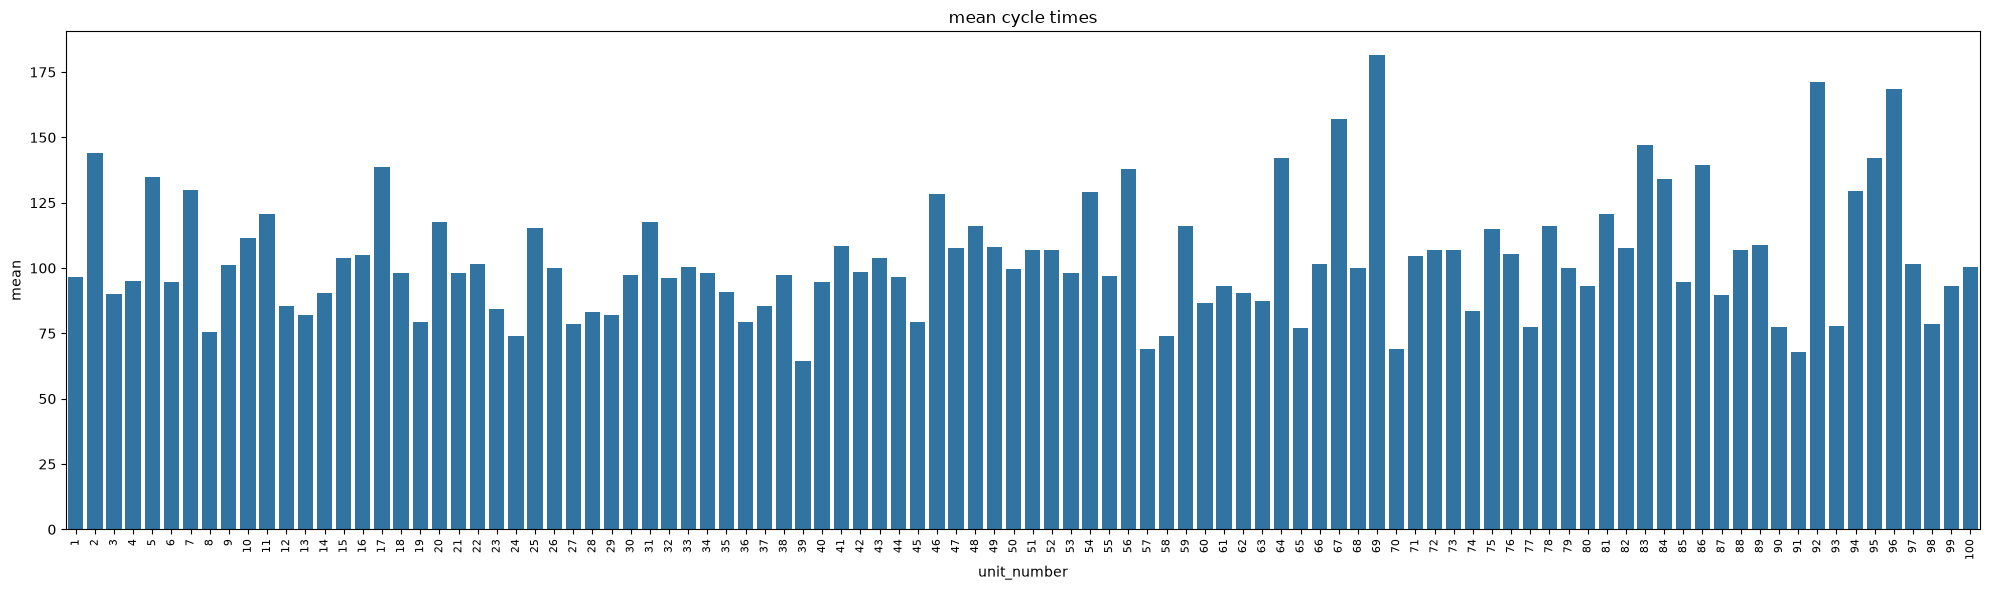

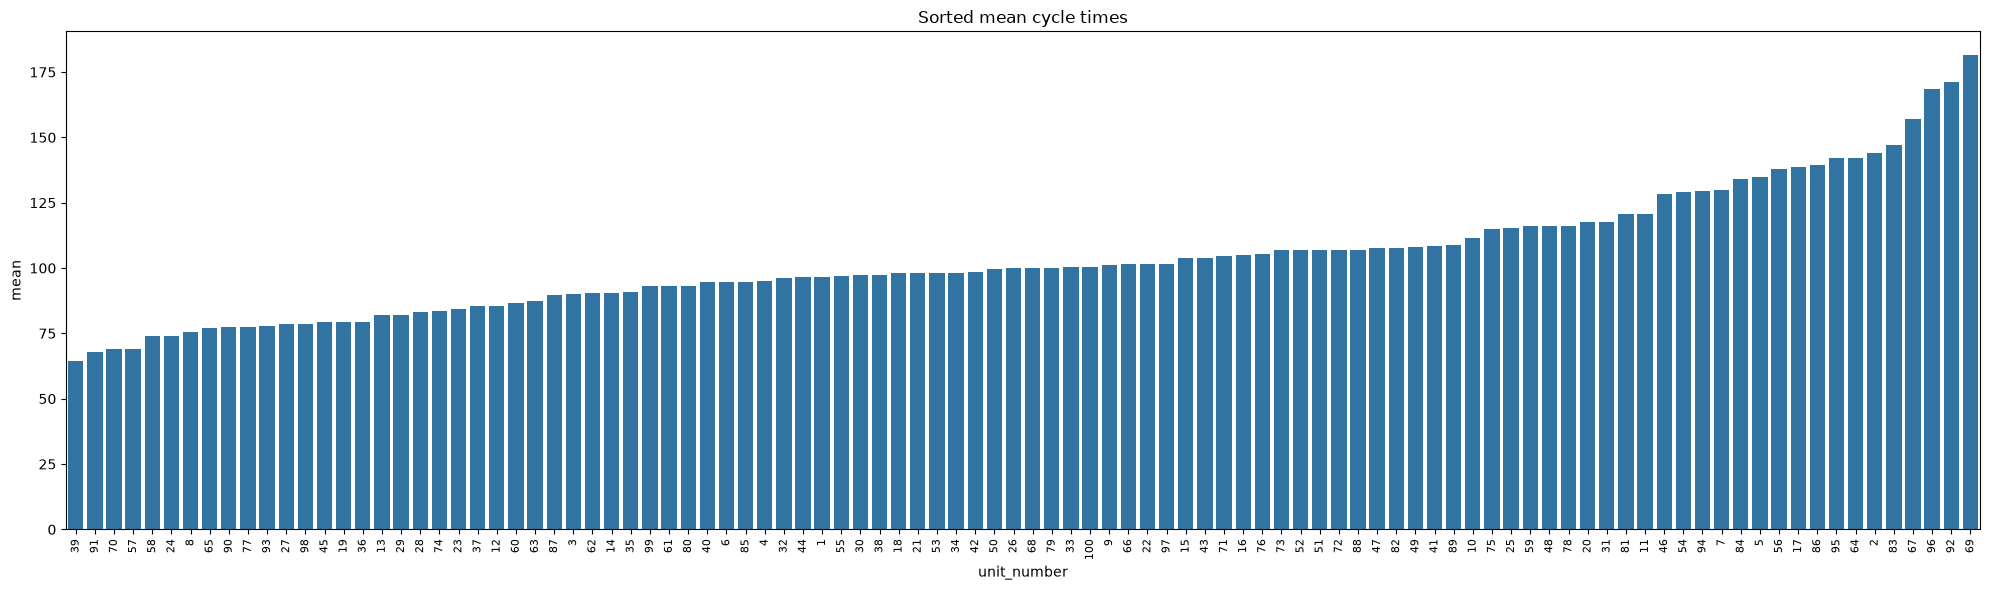

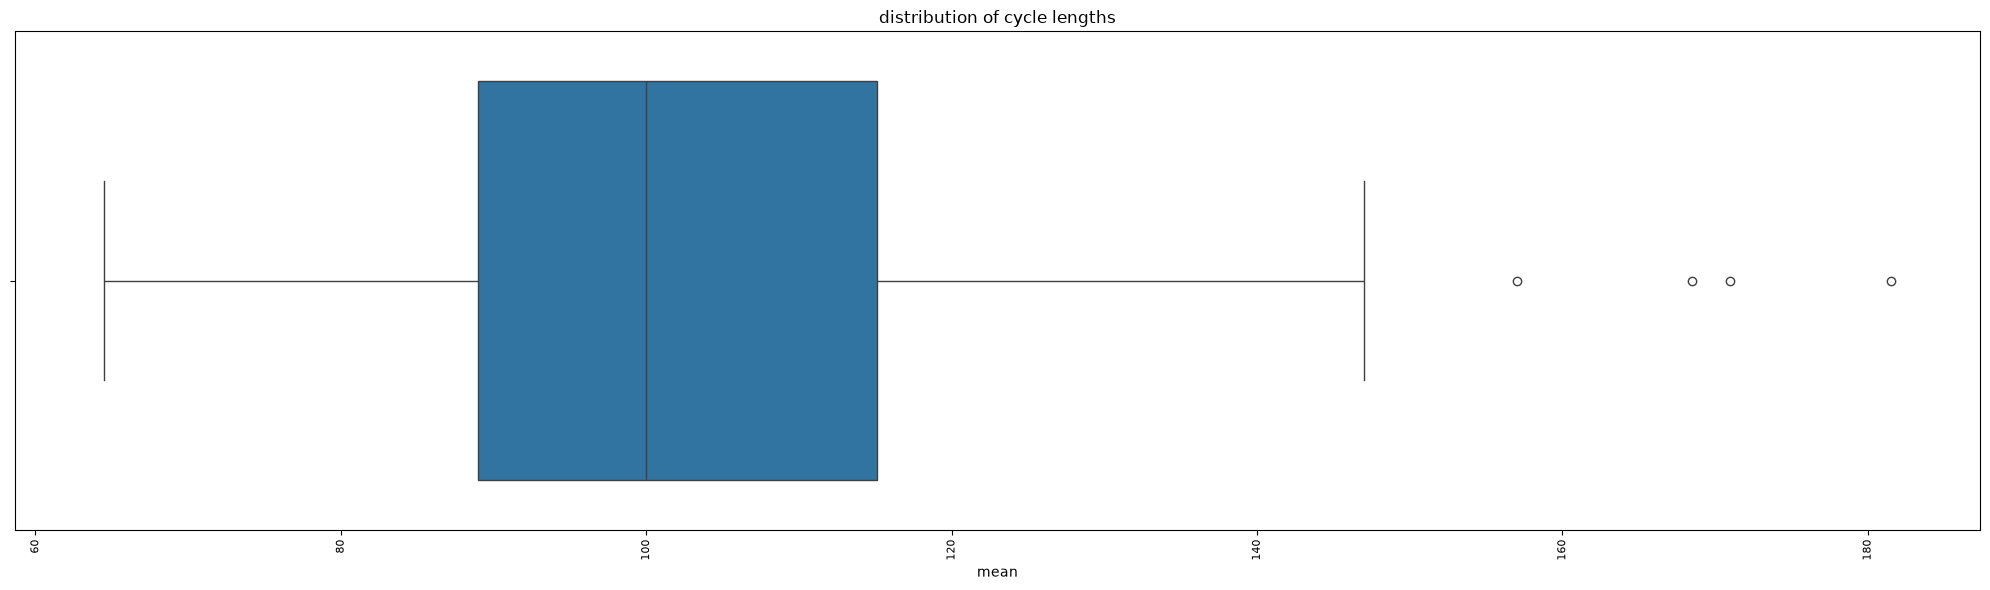

Outliers:              count   mean         std  min    25%    50%     75%    max
unit_number                                                            
67           313.0  157.0   90.499540  1.0  79.00  157.0  235.00  313.0
69           362.0  181.5  104.644637  1.0  91.25  181.5  271.75  362.0
92           341.0  171.0   98.582453  1.0  86.00  171.0  256.00  341.0
96           336.0  168.5   97.139076  1.0  84.75  168.5  252.25  336.0


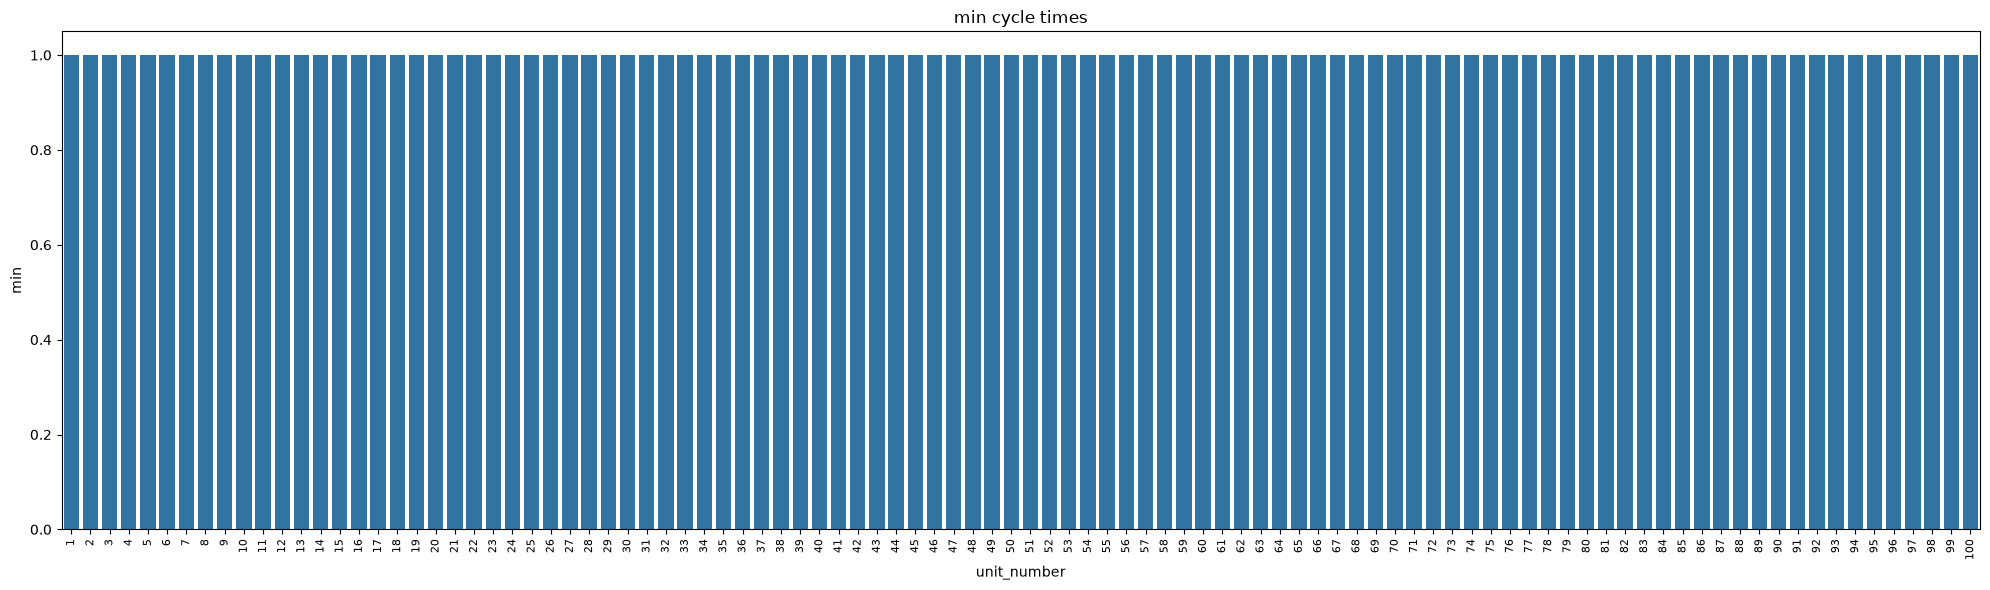

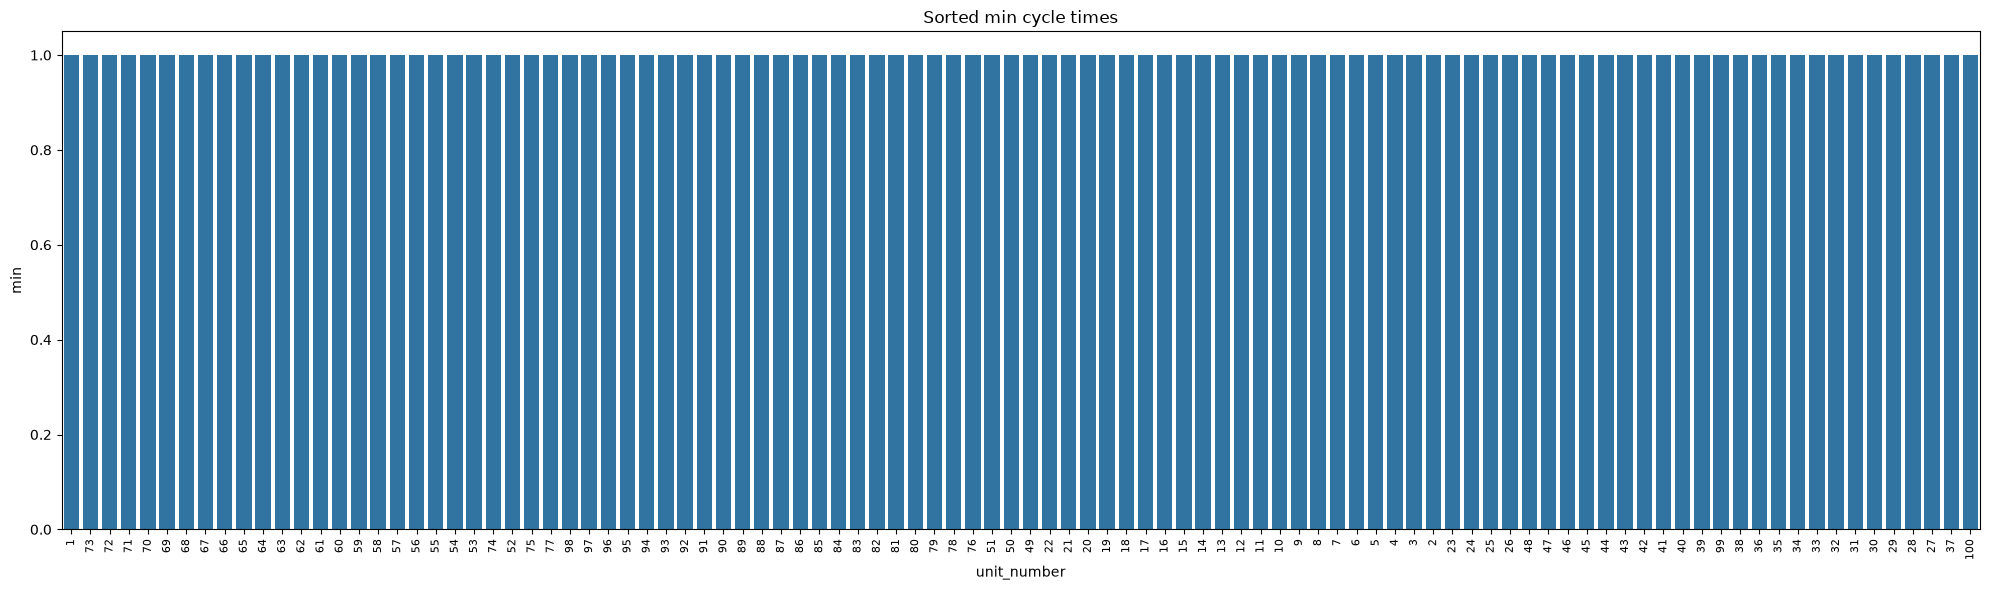

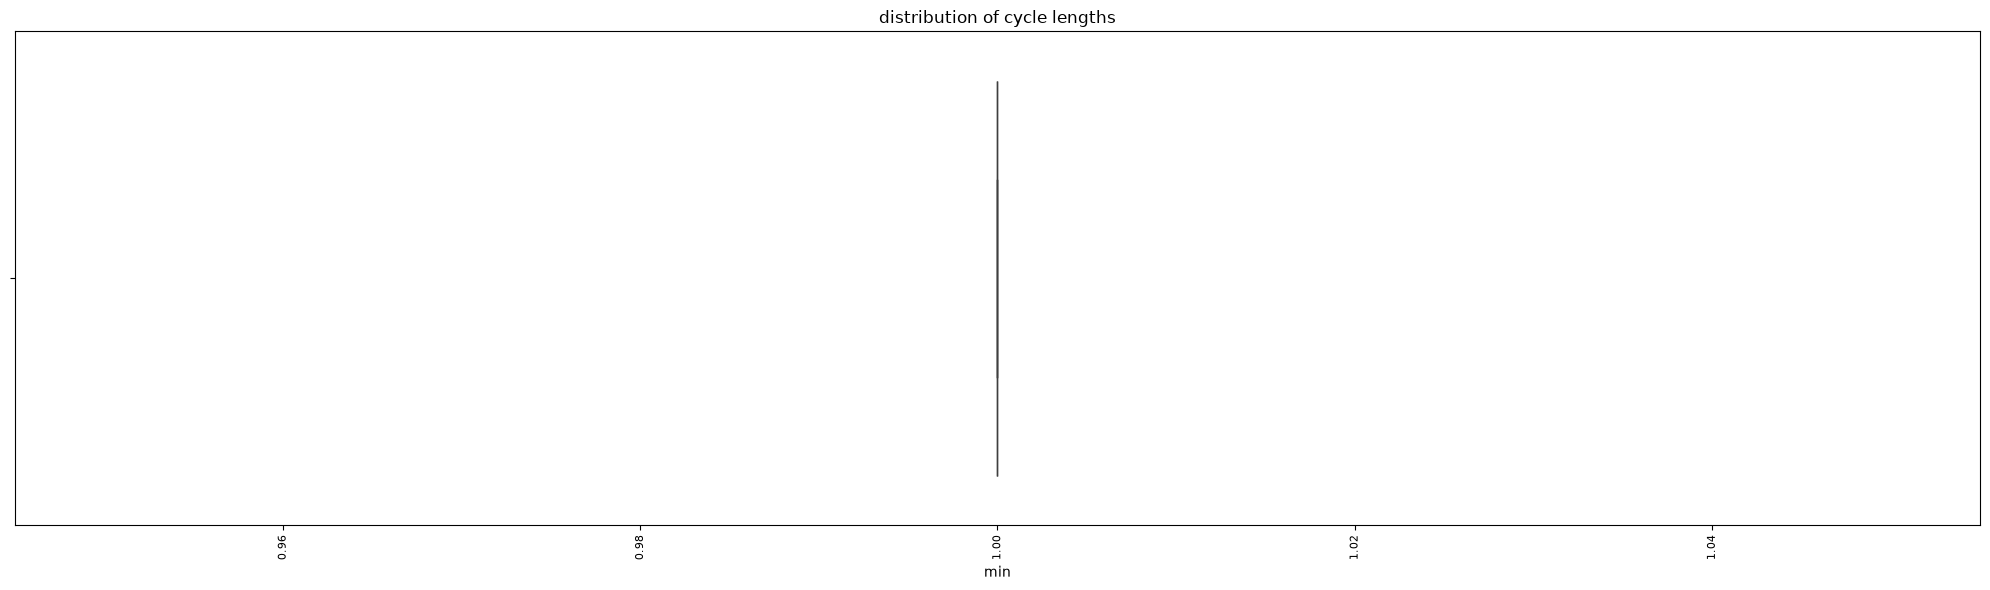

Outliers: Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []


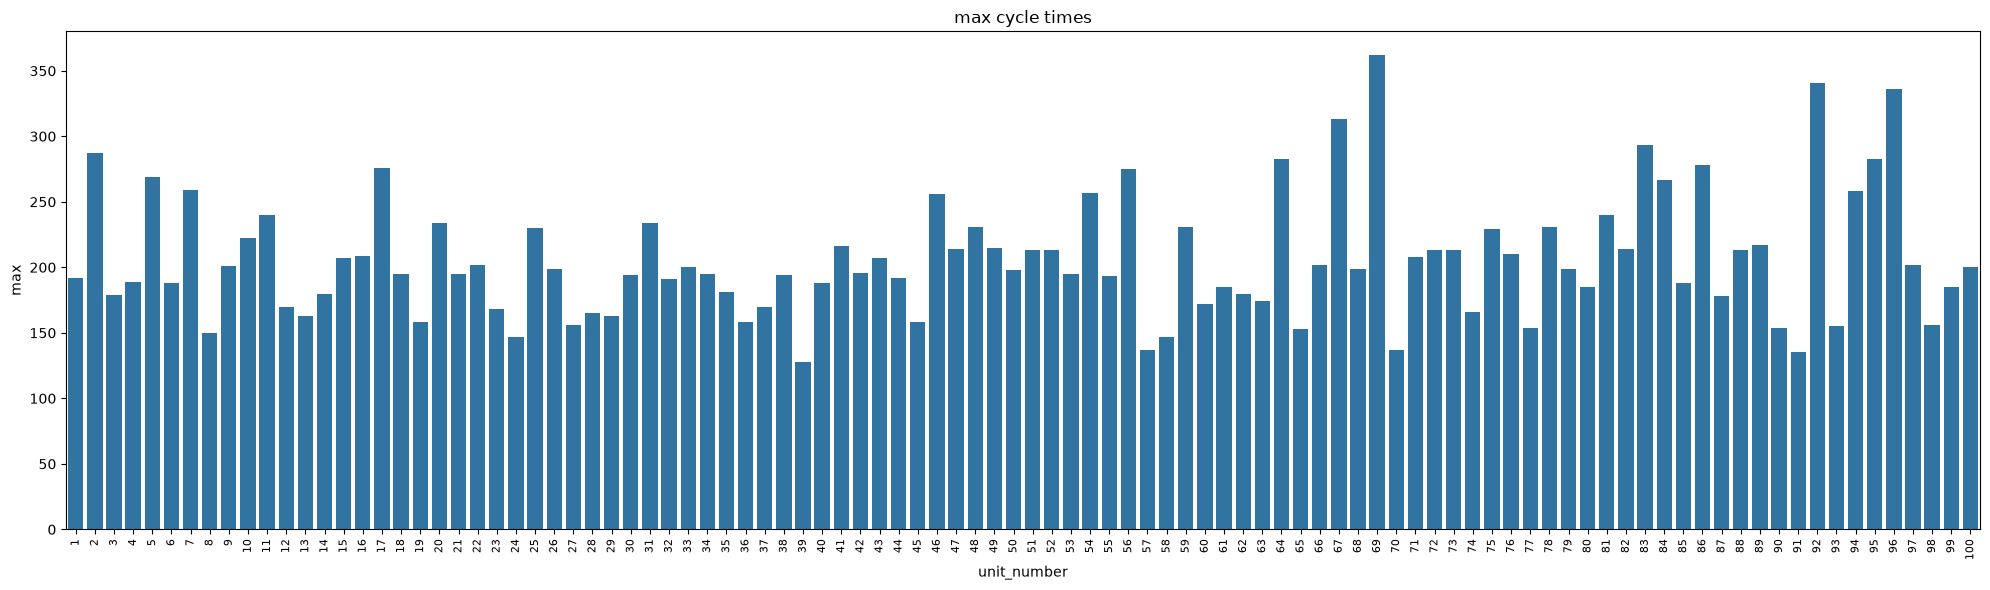

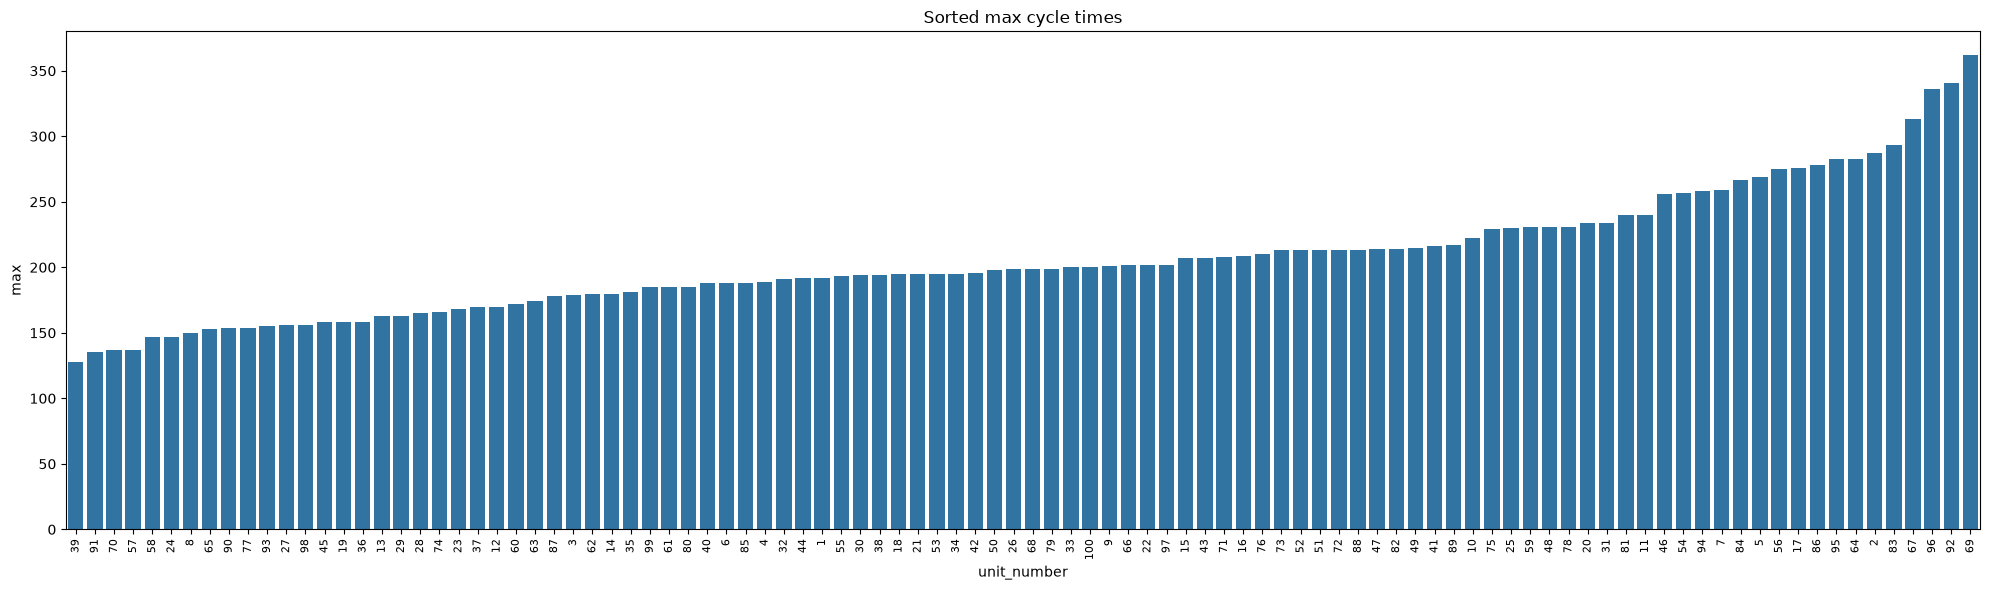

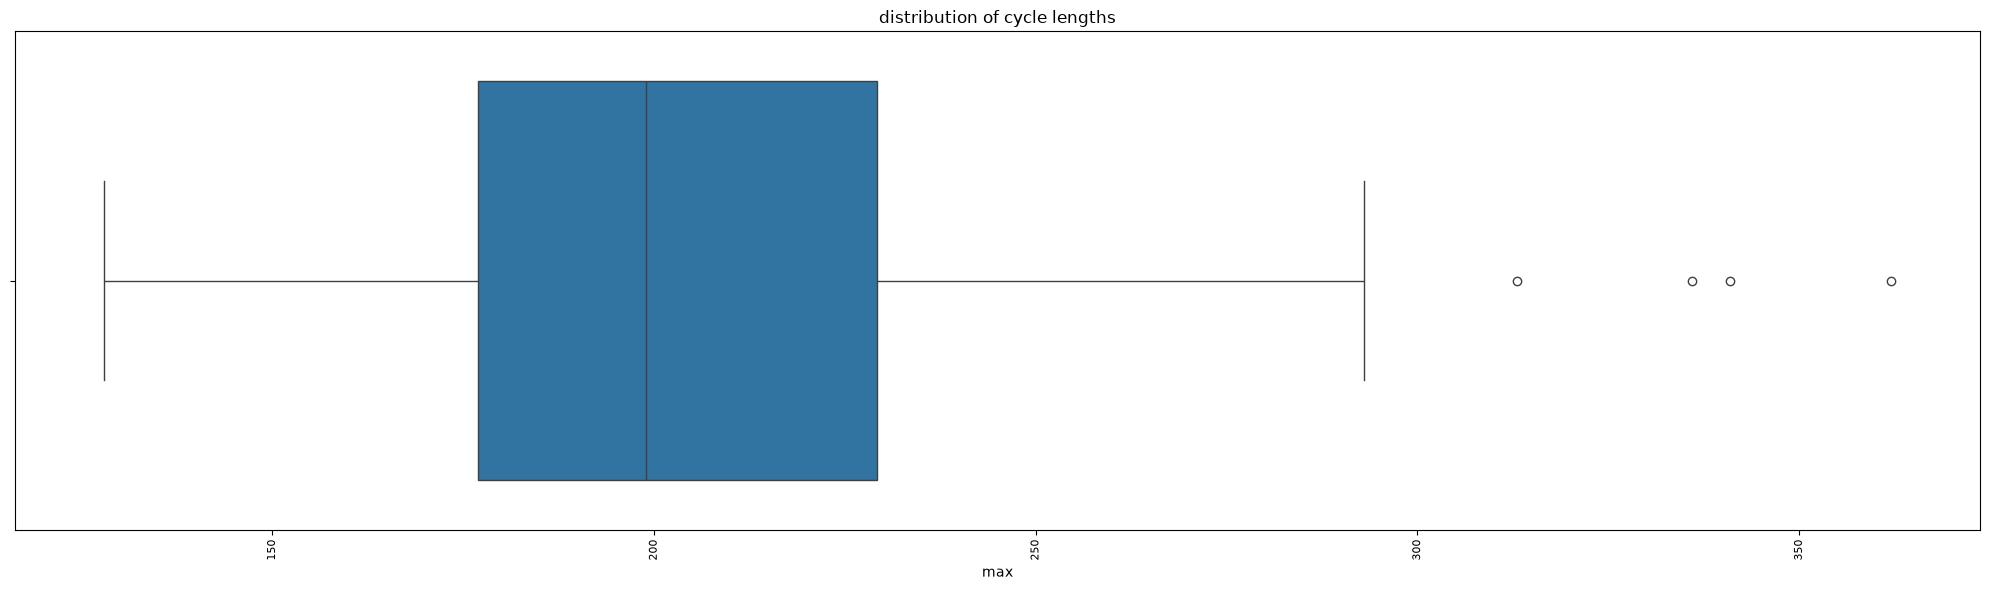

Outliers:              count   mean         std  min    25%    50%     75%    max
unit_number                                                            
67           313.0  157.0   90.499540  1.0  79.00  157.0  235.00  313.0
69           362.0  181.5  104.644637  1.0  91.25  181.5  271.75  362.0
92           341.0  171.0   98.582453  1.0  86.00  171.0  256.00  341.0
96           336.0  168.5   97.139076  1.0  84.75  168.5  252.25  336.0


In [9]:
plot_cycles('mean')
plot_cycles('min')
plot_cycles('max')

The sensors that seem to correlate the most with RUL are sensors 11, 4, 12, 7, and 15. The sensors that correlate the least are sensors 6, 14, 9, 13, and 8.

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
dtype: float64


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'sensor_11'),
  Text(1, 0, 'sensor_4'),
  Text(2, 0, 'sensor_15'),
  Text(3, 0, 'sensor_2'),
  Text(4, 0, 'sensor_17'),
  Text(5, 0, 'sensor_3'),
  Text(6, 0, 'sensor_8'),
  Text(7, 0, 'sensor_13'),
  Text(8, 0, 'sensor_9'),
  Text(9, 0, 'sensor_14'),
  Text(10, 0, 'sensor_6'),
  Text(11, 0, 'sensor_20'),
  Text(12, 0, 'sensor_21'),
  Text(13, 0, 'sensor_7'),
  Text(14, 0, 'sensor_12')])

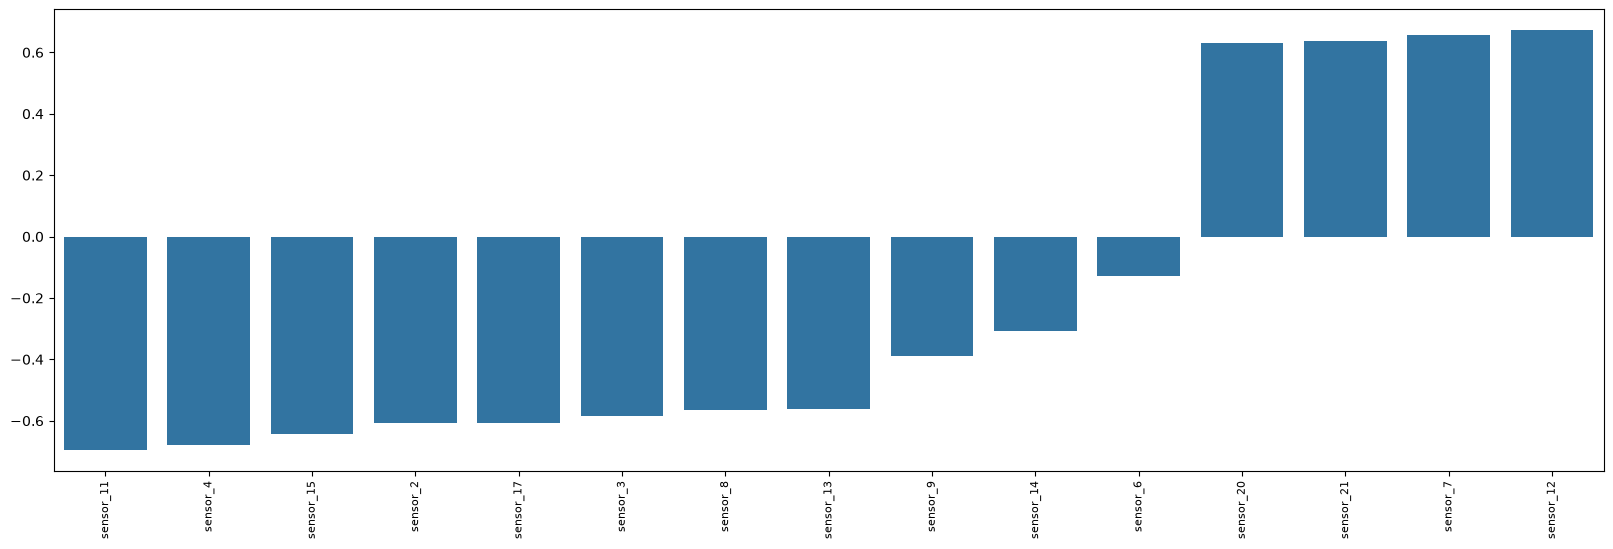

In [10]:
sensor_list = train.columns.tolist()[3:-1]
RUL_correlation = train[sensor_list].corrwith(train['RUL']).sort_values()
print(RUL_correlation)
plt.figure(figsize=(20, 6))
sns.barplot(RUL_correlation)
plt.xticks(rotation=90, fontsize=8)

The sensors with the highest correlation with each other are sensors 11 and 12, 7 and 11, 4 and 11, 8 and 13, 4 and 12. So the sensors that are the most highly correlated are sensors 11, 12, 7, 4, 8 and 13.

<Axes: >

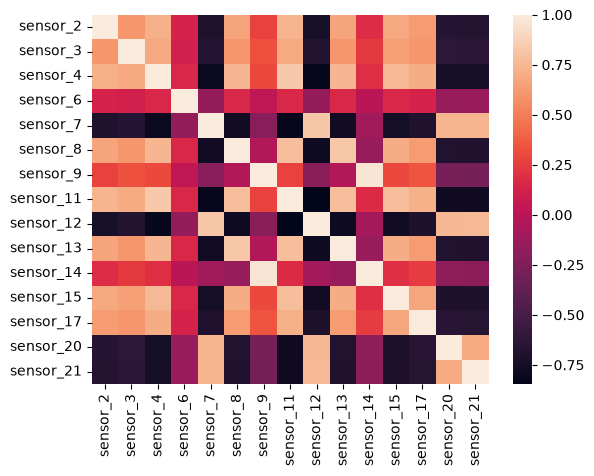

In [11]:
correlation_matrix = train[sensor_list].corr(method='pearson')
sns.heatmap(correlation_matrix)

In [12]:
print(correlation_matrix.round(2))

           sensor_2  sensor_3  sensor_4  sensor_6  sensor_7  sensor_8  \
sensor_2       1.00      0.60      0.71      0.13     -0.70      0.66   
sensor_3       0.60      1.00      0.68      0.12     -0.66      0.60   
sensor_4       0.71      0.68      1.00      0.15     -0.79      0.75   
sensor_6       0.13      0.12      0.15      1.00     -0.16      0.15   
sensor_7      -0.70     -0.66     -0.79     -0.16      1.00     -0.77   
sensor_8       0.66      0.60      0.75      0.15     -0.77      1.00   
sensor_9       0.27      0.32      0.30      0.02     -0.22     -0.03   
sensor_11      0.74      0.70      0.83      0.16     -0.82      0.78   
sensor_12     -0.72     -0.68     -0.82     -0.16      0.81     -0.79   
sensor_13      0.66      0.60      0.75      0.16     -0.76      0.83   
sensor_14      0.18      0.24      0.19     -0.00     -0.11     -0.14   
sensor_15      0.68      0.64      0.76      0.15     -0.75      0.70   
sensor_17      0.63      0.60      0.70      0.13  

In [13]:
def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(correlation_matrix))

Top Absolute Correlations
sensor_11  sensor_12    0.996852
sensor_7   sensor_11    0.995901
sensor_4   sensor_11    0.995433
sensor_8   sensor_13    0.995064
sensor_4   sensor_12    0.994816
dtype: float64


It seems that until around cycle 200, the sensor is increasing at an exponential rate with little variation, but passed that point, the growth slows and there is a higher variation.

In [14]:
def plot_sensor_engine(engine_number, sensor_number):
    engine = train[train.unit_number == engine_number]
    engine.plot(
        x="time_cycles",
        y=sensor_number,
        subplots=True,
        figsize=(4, 3),
        title=f"Engine 1 {sensor_number} readings over its life"
    )
    plt.show()

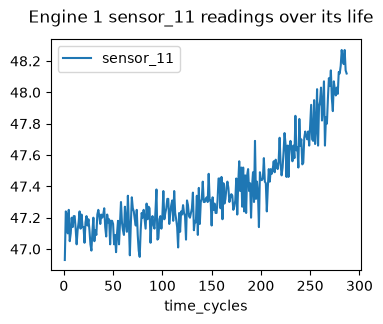

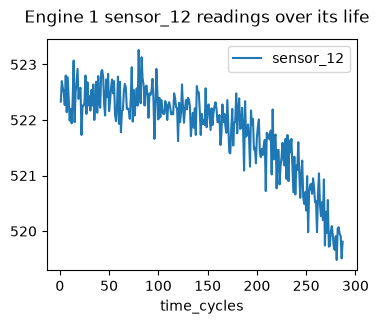

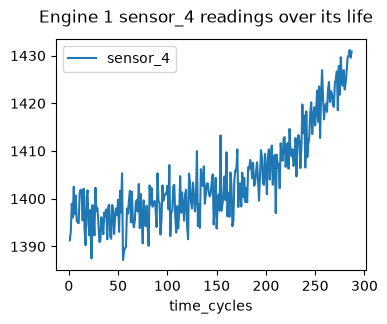

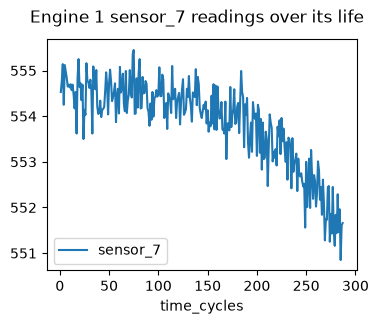

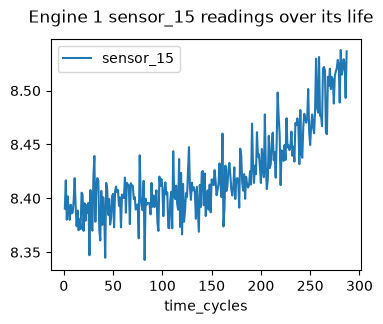

In [15]:
sensors_to_plot = ["sensor_11", "sensor_12", "sensor_4", "sensor_7", "sensor_15"]
for s in sensors_to_plot:
    plot_sensor_engine(engine_number=2, sensor_number=s)

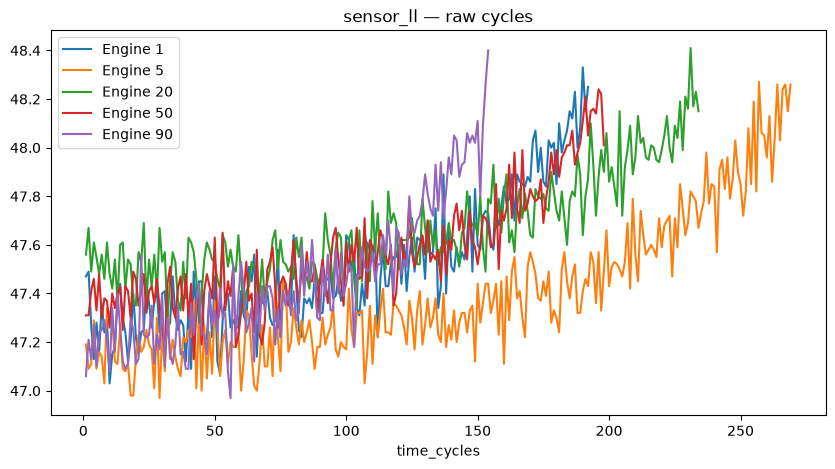

In [16]:
plt.figure(figsize=(10, 5))
for engine_id in [1, 5, 20, 50, 90]:
    e = train[train.unit_number == engine_id]
    plt.plot(e["time_cycles"], e['sensor_11'], label=f"Engine {engine_id}")
plt.legend()
plt.title(f"{'sensor_ll'} — raw cycles")
plt.xlabel("time_cycles")
plt.show()

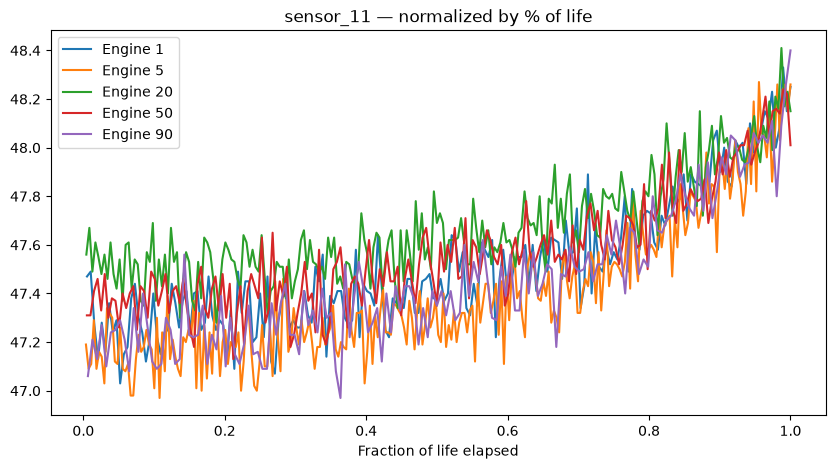

In [17]:
plt.figure(figsize=(10, 5))
for engine_id in [1, 5, 20, 50, 90]:
    e = train[train.unit_number == engine_id]
    pct_life = e["time_cycles"] / e["time_cycles"].max()  # 0 = start of life, 1 = failure
    plt.plot(pct_life, e['sensor_11'], label=f"Engine {engine_id}")
plt.legend()
plt.title(f"{'sensor_11'} — normalized by % of life")
plt.xlabel("Fraction of life elapsed")
plt.show()

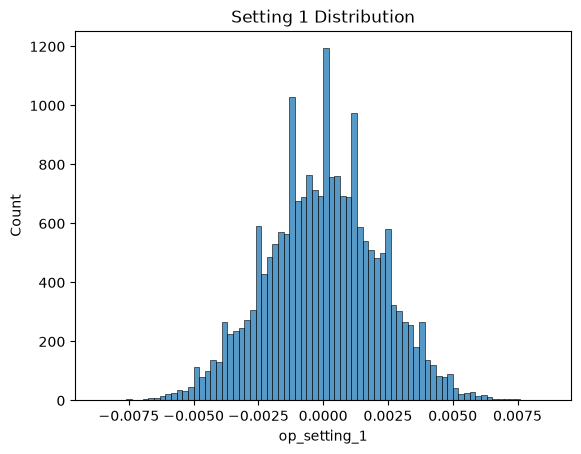

[Text(0.5, 1.0, 'Setting 1 Distribution')]

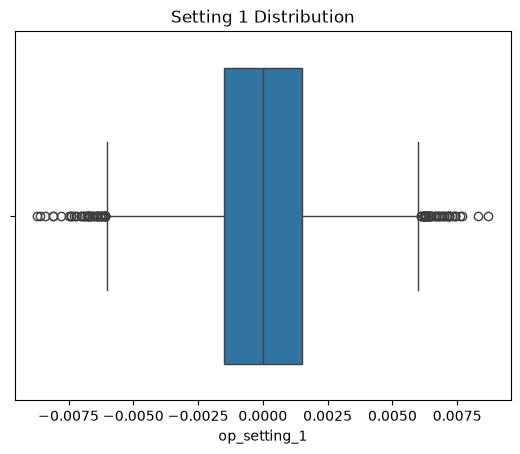

In [18]:
sns.histplot(data=train, x='op_setting_1').set(title='Setting 1 Distribution')
plt.show()
sns.boxplot(data=train, x='op_setting_1').set(title='Setting 1 Distribution')

Train lengths (full lifespans):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64

Test lengths (truncated, before failure):
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: time_cycles, dtype: float64


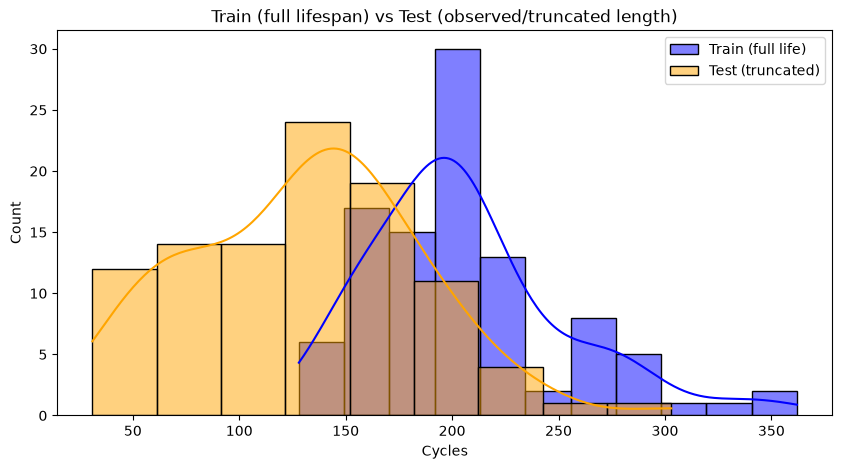

Test true full lifespans (observed + remaining):
count    100.000000
mean     206.480000
std       44.041872
min      141.000000
25%      174.750000
50%      199.000000
75%      227.750000
max      341.000000
dtype: float64

Train true full lifespans:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64
count    100.000000
mean       0.627564
std        0.215625
min        0.206704
25%        0.457435
50%        0.619989
75%        0.826351
max        0.966667
dtype: float64


In [19]:
train_lengths = train.groupby("unit_number")["time_cycles"].max()
test_lengths = test.groupby("unit_number")["time_cycles"].max()

print("Train lengths (full lifespans):")
print(train_lengths.describe())

print("\nTest lengths (truncated, before failure):")
print(test_lengths.describe())

plt.figure(figsize=(10, 5))
sns.histplot(train_lengths, color="blue", label="Train (full life)", alpha=0.5, kde=True)
sns.histplot(test_lengths, color="orange", label="Test (truncated)", alpha=0.5, kde=True).set_title("Train (full lifespan) vs Test (observed/truncated length)")
plt.xlabel("Cycles")
plt.legend()
plt.show()

rul_indexed = rul.copy()
rul_indexed.index = rul_indexed.index + 1  # match unit_number (1-indexed, not 0-indexed)

test_true_full_life = test_lengths + rul_indexed["RUL"]

print("Test true full lifespans (observed + remaining):")
print(test_true_full_life.describe())

print("\nTrain true full lifespans:")
print(train_lengths.describe())

pct_observed = test_lengths / test_true_full_life
print(pct_observed.describe())

## Models

### Multiple Linear Regression

Multiple linear regression was chosen as a baseline for modeling the data. Specifically for time series data, it is beneficial for being highly interpretable and simple, as well as being fast and efficient. From the previous analysis, we found that the scales for the sensors are very different from each other, so normalizing is required. Many of the sensors are also highly correlated with eachother (11, 4, 12, etc.), so multicolinearity needs to be dealt with. The easiest way to deal with this would be to use Variance Inflation Factor (VIF) and drop the fetures with the highest VIF scores. However, even manually removing the highest VIF scores, resulted in 2 features with VIF scores in the 9000s, so a better way to handle the multicolinearity may be to use Ridge Regression since it's better able to handle multicollinearity. Cross validation is also used to pick the best penalty term.

Lasso deals with multicolinearity by arbitrarily selecting one feature and zeroes out the rest. The issue with this is that slight changes in the data can drastically flip a variable in or out of the model. Ridge deals with multicolinearity by shrinking coefficients, causing correlated features to move closer to zero without removing them, the issue being that variance is reduced and a bias is introduced. Ridge is more stable compared to Lasso, however, both were tested. Ridge and Lasso performed about the same with an R-squared score of about 0.47. The Ridge MSE score was approximately 1840.72 which is approximately the same as the score for lasso, 1839.79.

Elastic Net CV is a combination of Lasso and Ridge and was used to see if the issues of both could be minimized. Elastic Net CV benefits in this situation, because it drives unimportant features to zero, allowing for the model to be simpler, but also uses the Rige penalty component to keep correlated features together, rather than making a random choice on which feature is kept. It got an R-Squared score of approximately 0.46 and an MSE of approximately 1862.91. 

The main issue with these models seems to be the large amount of multicollinearity and the fact that the relationship between the features of these models is not linear. From the sensors, it seems that sensors 4, 7, 11, 2, and 15 were the strongest predictors for RUL because they were the most correlated, however all of them were heavily correlated with each other.

In [20]:
#Manually dropping features until a VIF score until a VIF score is lower than the threshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
columns_to_drop = ['sensor_13', 'sensor_8', 'sensor_6', 'sensor_14', 'sensor_2', 'sensor_12', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_17', 'sensor_3', 'sensor_15', 'sensor_21']
X = train[sensor_cols].copy().drop(columns=columns_to_drop)
vif_data = pd.DataFrame()
vif_data['features'] = X.columns
vif_data['vif_scores'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('vif_scores', ascending=False))

    features   vif_scores
0   sensor_4  9347.051654
1  sensor_20  9347.051654


In [21]:
#Normalizing data using standard scaler and removing unit numbers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

scaler = StandardScaler()

X_train= train.copy().drop(columns=['RUL', 'unit_number'])
y_train = train['RUL']
X_test = test.copy().drop(columns=['RUL', 'unit_number'])
y_test = test['RUL']

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import RidgeCV, LassoCV

#fitting ridge model
ridge = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10, 50, 100, 500, 1000]).fit(X_train_scaled, y_train)
lasso = LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10, 50, 100, 500, 1000], cv=10).fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge Regression MSE: {mse:.4f}")
y_pred_lasso = lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso Regression MSE: {mse:.4f}")

#Scores
print("Ridge Best Alpha:", ridge.alpha_)
print("Ridge R2 Score:", ridge.score(X_test_scaled, y_test))
print("Lasso Best Alpha:", lasso.alpha_)
print("Lasso R2 Score:", lasso.score(X_test_scaled, y_test))


Ridge Regression MSE: 1840.7216
Lasso Regression MSE: 1839.7905
Ridge Best Alpha: 100.0
Ridge R2 Score: 0.47081191891739904
Lasso Best Alpha: 0.1
Lasso R2 Score: 0.4710795841866906


In [23]:
from sklearn.linear_model import ElasticNetCV

ENCV = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0], alphas=100, cv=18, n_jobs=-1, random_state=42)
ENCV.fit(X_train_scaled, y_train)

print(f"Optimal Alpha: {ENCV.alpha_}")
print(f"Optimal L1 Ratio: {ENCV.l1_ratio_}")

train_score = ENCV.score(X_train_scaled, y_train)
test_score = ENCV.score(X_test_scaled, y_test)
print(f"Train R^2: {train_score:.4f} | Test R^2: {test_score:.4f}")

y_pred_ENCV= ENCV.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_ENCV)
print(f"Elastic Net CV Regression MSE: {mse:.4f}")

Optimal Alpha: 0.17945268986468624
Optimal L1 Ratio: 0.7
Train R^2: 0.6548 | Test R^2: 0.4644
Elastic Net CV Regression MSE: 1862.9065


### Random Forest Regressor

Random Forest Regressor has the advantages of being simple, but having a high resistance towards noise/outliers and being able to model non linear patterns. It is very resistant towards overfitting, and it automatically estimates how much each variable contributes to the model's ability to predict. Grid Search CV and Group k fold was used to optimize the parameters of the model. The R-squared value for this model was approximately 0.52 and the MSE score was approximately 1409.18. Sensors 11, 9, 12, 4, and 14 were the most informative for the model and helped assist the most with predictions. One interesting thing to note is that all of these sensors are highly correlated with each other.

Adding caps to the cyces was also tested, since some engines run much longer compared to others. The cycles were clipped at 125 cycles. This definitely improved the model significantly, increasing the R-squared score by 0.1 to approximately 0.61, as well as giving the MSE score of approximately 1757.33. This shows that the the range for RUL varying significantly between engines was a real challenge that the model struggled with–especially with engines that ran for much longer.

Adding windows to the model was also tested with rolling mean and standard deviation, however this did not improve the model; in fect it made it perform worse. This is likely due to this tree model being able to extract this trend information from the raw sensor values itself. It seems that this model didn't require manual smoothening to improve performance. The R-squared value was approximately 0.497 and the MSE value was approximately 1448.08. The sensors that provided the most information for the model's predictions were sensors 4, 11, 12, 9, and 14, which were the same as the original Random Forest Regressor model, however sensors 4, 11, and 12's rolling means were more informative.

In [24]:
#Basic Random Forest Regressor Model No tuning
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(n_estimators=115, max_depth=4, random_state=42, min_samples_leaf=100)
rf.fit(X_train, y_train)

train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)
print(f"Train R^2: {train_score:.4f} | Test R^2: {test_score:.4f}")

y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Random Forest MSE: {mse:.4f}")

Train R^2: 0.7045 | Test R^2: 0.4948
Random Forest MSE: 1757.3331


In [25]:
#Random forest regressor capped
from sklearn.ensemble import RandomForestRegressor

#cap dataset
y_train_capped = train["RUL"].clip(upper=125)
y_test_capped = test["RUL"].clip(upper=125)

#fit and train the model
rf = RandomForestRegressor(n_estimators=115, max_depth=4, random_state=42, min_samples_leaf=100)
rf.fit(X_train, y_train_capped)

#score the model for training and testing data
train_score = rf.score(X_train, y_train_capped)
test_score = rf.score(X_test, y_test_capped)
print(f"Train R^2: {train_score:.4f} | Test R^2: {test_score:.4f}")

y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test_capped, y_pred)
print(f"Random Forest MSE: {mse:.4f}")

Train R^2: 0.8158 | Test R^2: 0.6050
Random Forest MSE: 300.4214


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV

#Create a parameter grid to find teh best parameters
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10, 20],
}
group_kfold = GroupKFold(n_splits=5)
rf = RandomForestRegressor(n_estimators=115, max_depth=4, random_state=42, min_samples_leaf=100)

#Grid search and cross validation using group k fold to find the best parameters
rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=group_kfold,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
#Fit and train model
rf.fit(X_train, y_train, groups=train["unit_number"])
print("Best params:", rf.best_params_)
print("Best CV score (neg MSE):", rf.best_score_)

#calculate scores for model
best_rf = rf.best_estimator_
print("Test R^2:", best_rf.score(X_test, y_test))

Best params: {'max_depth': 10, 'min_samples_leaf': 20, 'n_estimators': 300}
Best CV score (neg MSE): -1409.1793752659464
Test R^2: 0.5191438140291624


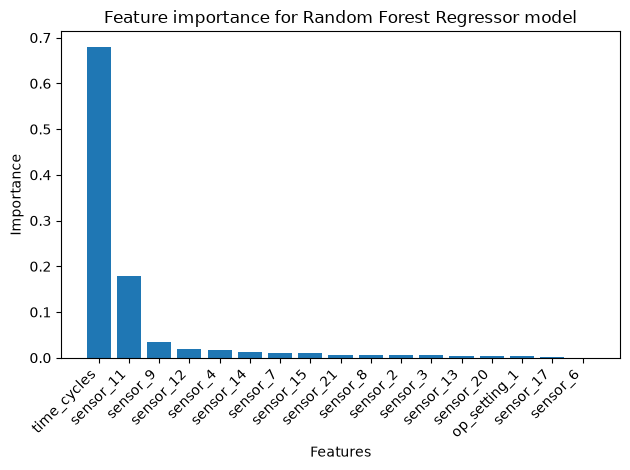

In [27]:
#Graph of feature importance to model
feature_importance = best_rf.feature_importances_
feature_imp_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)
plt.bar(x="Feature", height="Importance", data=feature_imp_rf)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature importance for Random Forest Regressor model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout() 
plt.show()

In [28]:
#create copies so original train/test stay untouched
train_fe = train.copy()
test_fe = test.copy()

#Recompute top sensors by RUL correlation
sensor_cols = train_fe.filter(like="sensor_").columns
rul_correlation_ranked = train_fe[sensor_cols].corrwith(train_fe["RUL"]).abs().sort_values(ascending=False)
top_sensors = rul_correlation_ranked.head(4).index.tolist()
print("Top sensors:", top_sensors)

#Add rolling window features for train_fe and test_fe
window = 5
for sensor in top_sensors:
    train_fe[f"{sensor}_rollmean"] = train_fe.groupby("unit_number")[sensor].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    train_fe[f"{sensor}_rollstd"] = train_fe.groupby("unit_number")[sensor].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    ).fillna(0)  # first row per engine has no std yet; fill with 0

    test_fe[f"{sensor}_rollmean"] = test_fe.groupby("unit_number")[sensor].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    test_fe[f"{sensor}_rollstd"] = test_fe.groupby("unit_number")[sensor].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    ).fillna(0)

#Rebuild feature set
feature_cols = [c for c in train_fe.columns if c not in ["unit_number", "RUL"]]

X_train_fe = train_fe[feature_cols]
y_train_fe = train_fe["RUL"]
X_test_fe = test_fe[feature_cols]
y_test_fe = test_fe["RUL"]

print("X_train shape:", X_train_fe.shape)
print("Feature columns:", X_train_fe.columns.tolist())

#create a parameter grid to find best parameters
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10, 20],
}
#use group k fold cross validation and grid search to find optimal parameters
group_kfold = GroupKFold(n_splits=5)
rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=group_kfold,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

#train and fit model
rf.fit(X_train_fe, y_train_fe, groups=train_fe["unit_number"])
print("Best params:", rf.best_params_)
print("Best CV score (neg MSE):", rf.best_score_)

#calculate score for model
best_rf = rf.best_estimator_
print("Test R^2:", best_rf.score(X_test_fe, y_test_fe))


Top sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']
X_train shape: (20631, 25)
Feature columns: ['time_cycles', 'op_setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_11_rollmean', 'sensor_11_rollstd', 'sensor_4_rollmean', 'sensor_4_rollstd', 'sensor_12_rollmean', 'sensor_12_rollstd', 'sensor_7_rollmean', 'sensor_7_rollstd']
Best params: {'max_depth': 10, 'min_samples_leaf': 20, 'n_estimators': 300}
Best CV score (neg MSE): -1448.0755546033247
Test R^2: 0.4971377593778895


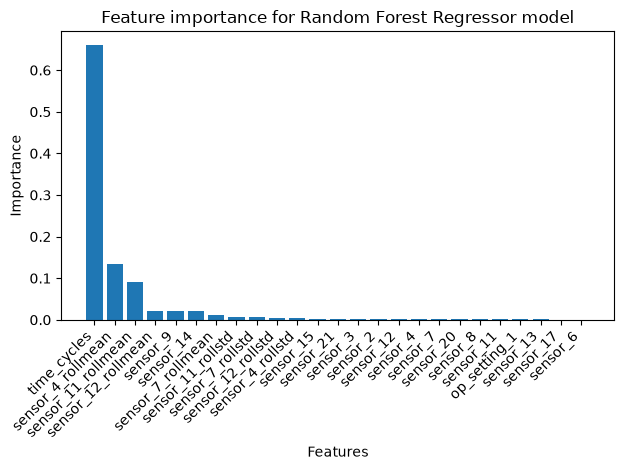

In [29]:
#graph of most important features to model
feature_importance = best_rf.feature_importances_
feature_imp_rf = pd.DataFrame({
    "Feature": X_train_fe.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)
plt.bar(x="Feature", height="Importance", data=feature_imp_rf)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature importance for Random Forest Regressor model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout() 
plt.show()

### XG Boost

Random Forest is a powerful tree model. Tree models are well known for being quite robust, so the next step to improvement would be to use a boosted tree model. Two were chosen: XGB Regressor and XGB Random Forest. The purpose in boosting a model is convert a weaker, simpler model into a highly accurate predictor with low error. One particular benefit is that trees are built sequentially rather than all at once, as they are with Random Forest models, which corrects for the error in later trees, allowing for less bias and a better fit of the data. Grid search and group k folds was used to pick the best parameters for both models. The R-squared value for XGB Regressor was approximately 0.529 and the RMSE score was approximately 40.492. Group Shuffle Split with early stopping was also used after as a sanity check to see if the model is able to generalize. Early stopping on the held out validation split resulted in an R-squared value and RMSE value (~0.527 and ~40.573) similar to the R-squared value and RMSE value achieved earlier for XGB Regressor, suggesting that the parameters are robust and the model is not overfitting. The most important sensors were 14, 9, 11, 13, and 4. Other than sensor 13, this seems to align with the sensors that were the most useful as predictors for Random Forest.

Windowing was also tested with XGB Regressor. Using windows of 5, 10, and 20, the Mean and Standard deviation were calculated for all the sensors. XGB Regressor was trained using these new features as well as the prior features. However, the model performed on par with these new features as without. The R-squared value was approximately 0.523 and the RMSE value was approximately 40.72. When looking at the feature importance graphs, it seems that the features in the feature engineered data had less importance to the model compared to the default model. For example, the sensor with the highest importance in the default model was sensor 14, with a score of 127, however the sensor with the highest importance in the feature engineered model was sensor 14 with a rolling mean of 20 (window size) which has an importance score of 21. The features being most important to the model's predictive power were sensor 14 (Rolling mean, window size 20), sensor 11 (Rolling mean, window size 5), sensor 9(standard deviation, window size 20), sensor 13 (Rolling mean, window size 5), sensor 2 (Rolling mean, window size 20). Other than sensor 2, these are the same sensors that provided the most importance to the predictive power of the default model. It also seems that standard deviation for the most part didn't provide as much importance to the model's predictive power. This suggests that the model is relying more the sensor's value centered or trending rather than how much the sensor is moving around. When looking at graphs of the sensor data (specifically sensor 11), there was increasing volatility as well as an upward drift as the engine approached the end of it's usage, but it could be getting mistaken for noise. We get 0.119 as the standard deviation in the first half of the signal and 0.243 in the second half. Standard deviation was probably not used as much by the model, due to how it is highly correlated with mean and time cycles, and the unique signal of standard deviation is much more limited compared to mean and not because volatility itself lacks predictive value, but because it is largely redundant with information already captured elsewhere. Slope and a percent-of-life-elapsed feature were also attempted, however slope caused severe overfitting and the percent-of-life-elapsed feature had a structural train/test mismatch and so both were removed. The slope feature produced extreme outliers due to it's instability in fitting a line in short and sometimes low variance windows. The percent-of-life-elapsed feature was defined in accordance with the engine's max cycle in the training dataset, which does not align with the test dataset since the test dataset stops the engine arbitrarily before true failure.

XGB Random Forest was also tested, however this model performed on par with XGB Regressor with an R-squared score of approximately 0.524 and an RMSE of approximately 40.673. This model probably didn't outperform XGB Regressor due to it's ability to minimize variance and prevent overfitting–this model is better suited a bench mark rather than one that can be used for maximum predictivea accuracy. The sensors that were most important towards the predictive power of the model were sensors 9, 11, 7, 14, and 4. This similar to the basic random forest model used earlier with the exception of sensor 7. However, unlike any of the other models, sensor 9 was considered more important compared to time cycles, which was consistently the feature given the highest importance for all the models. 

In [30]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
xgb.set_config(verbosity=2)

#Parameter grid for optimization
param_grid = {
    'max_depth': [2, 3],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 1.0],
    'min_child_weight': [0, 1, 5],
    'gamma': [0, 1, 5],
    'reg_alpha': [0.1, 1, 10],
    'reg_lambda': [10, 150]
}

#split data to find the best parameters
group_kfold = GroupKFold(n_splits=5)
xgbr = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgbr_grid = GridSearchCV(
    estimator=xgbr, param_grid=param_grid, cv=group_kfold, n_jobs=-1, verbose=1
)

#train and fit data
xgbr_grid.fit(X_train, y_train, groups=train["unit_number"])
print("Best parameters:", xgbr_grid.best_params_)

#Score model
y_pred = xgbr_grid.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')


Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
[17:43:23] INFO: /Users/ec2-user/croot/xgboost-split_1779289786370/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (20631, 17, 350727).
Best parameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 0, 'n_estimators': 50, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 1.0}
RMSE: 40.492
R²: 0.529


In [31]:
from sklearn.model_selection import GroupShuffleSplit

#Extract best model parameters
best = xgbr_grid.best_params_ 
best.pop('n_estimators', None) 

#group and split the data for validation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X_train, y_train, groups=train["unit_number"]))

X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

#create best model with best parameters
final_model = XGBRegressor(
    **best,                
    n_estimators=2000,    
    early_stopping_rounds=50, 
    eval_metric='rmse',
    objective='reg:squarederror',
    random_state=42
)

#fit and train the model
final_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],  
    verbose=False
)

#Score model
y_pred = final_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')
print("Best iteration:", final_model.best_iteration)


[17:43:24] INFO: /Users/ec2-user/croot/xgboost-split_1779289786370/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (16561, 17, 281537).
[17:43:24] INFO: /Users/ec2-user/croot/xgboost-split_1779289786370/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (4070, 17, 69190).
RMSE: 40.573
R²: 0.527
Best iteration: 64


In [32]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
xgb.set_config(verbosity=2)

param_grid = {
    'max_depth': [2, 3],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 1.0],
    'min_child_weight': [0, 1, 5],
    'gamma': [0, 1, 5],
    'reg_alpha': [0.1, 1, 10],
    'reg_lambda': [10, 150]
}
group_kfold = GroupKFold(n_splits=5)
xgbr = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgbr_grid = GridSearchCV(
    estimator=xgbr, param_grid=param_grid, cv=group_kfold, n_jobs=-1, verbose=1
)

xgbr_grid.fit(X_train, y_train, groups=train["unit_number"])
print("Best parameters:", xgbr_grid.best_params_)

y_pred = xgbr_grid.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')
#0.528

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
[17:46:34] INFO: /Users/ec2-user/croot/xgboost-split_1779289786370/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (20631, 17, 350727).
Best parameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 0, 'n_estimators': 50, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 1.0}
RMSE: 40.492
R²: 0.529


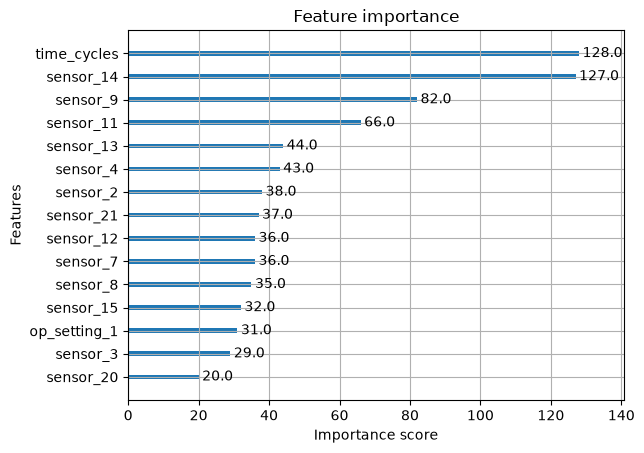

In [33]:
#plot feature importance
import matplotlib.pyplot as plt
xgb.plot_importance(final_model, max_num_features=15)
plt.show()

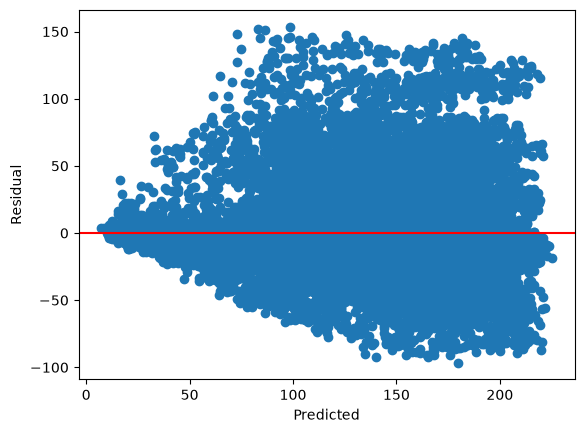

In [34]:
#plot residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel('Predicted'); plt.ylabel('Residual')
plt.show()

Using windows, use feature engineering for most important features (rolling mean, rolling std, rolling slope)

In [35]:
top_sensors = ['sensor_14', 'sensor_9', 'sensor_11', 'sensor_13', 'sensor_4', 'sensor_2']
feature_cols = ['time_cycles', 'op_setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 
                 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 
                 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
windows = [5, 10, 20]

#Build rolling mean/std features for train
for sensor in top_sensors:
    grp = train.groupby('unit_number')[sensor]
    for w in windows:
        train[f'{sensor}_roll_mean_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
        train[f'{sensor}_roll_std_{w}']  = grp.transform(lambda x: x.rolling(w, min_periods=1).std())

#Build rolling mean/std features for test
for sensor in top_sensors:
    grp = test.groupby('unit_number')[sensor]
    for w in windows:
        test[f'{sensor}_roll_mean_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
        test[f'{sensor}_roll_std_{w}']  = grp.transform(lambda x: x.rolling(w, min_periods=1).std())

#Build feature list
new_feature_cols = feature_cols + [
    col for col in train.columns 
    if '_roll_mean_' in col or '_roll_std_' in col
]

#Fill NaNs in the std columns (first row per engine has no std yet)
roll_std_cols = [c for c in new_feature_cols if '_roll_std_' in c]
train[roll_std_cols] = train[roll_std_cols].fillna(0)
test[roll_std_cols] = test[roll_std_cols].fillna(0)

X_train_new = train[new_feature_cols]
X_test_new = test[new_feature_cols]

#Parameter grid for optimization
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'n_estimators': [100, 200],
    'colsample_bytree': [0.6, 1.0],
    'reg_alpha': [1, 10],
    'reg_lambda': [10, 150]
}

#create and optimize model using group kfold and grid search cv
group_kfold = GroupKFold(n_splits=5)
xgbr_new = XGBRegressor(objective='reg:squarederror', random_state=42)
xgbr_model = GridSearchCV(
    estimator=xgbr_new, param_grid=param_grid, cv=group_kfold, n_jobs=-1, verbose=1
)

#Train and fit model
xgbr_model.fit(X_train_new, y_train, groups=train["unit_number"])
print("Best parameters:", xgbr_model.best_params_)

#scores
y_pred = xgbr_model.predict(X_test_new)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[17:46:53] INFO: /Users/ec2-user/croot/xgboost-split_1779289786370/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (20631, 53, 1093443).
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 10, 'reg_lambda': 150}
RMSE: 42.735
R²: 0.475


In [36]:
from sklearn.model_selection import RandomizedSearchCV

#parameter grid
param_grid = {
    'max_depth': [1, 2],
    'learning_rate': [0.045, 0.05, 0.055],
    'subsample': [0.4, 0.5, 0.55],
    'colsample_bytree': [0.5, 0.6, 0.7],
    'min_child_weight': [4, 5, 6],
    'gamma': [0, 1, 2],
    'reg_alpha': [0.04, 0.05, 0.06],
    'reg_lambda': [75, 100, 125]
    
}

#new model with more predictors
xgbr_new = XGBRegressor(n_estimators=200, objective='reg:squarederror', random_state=42)
#Randomized cearch to find best parameters
r_XGBR = RandomizedSearchCV(xgbr_new, param_distributions=param_grid, n_iter=100, scoring='neg_root_mean_squared_error', cv=group_kfold, verbose=2, n_jobs=-1)
#fit and train model
r_XGBR.fit(X_train_new, y_train, groups=train["unit_number"])
#scoring
y_pred = r_XGBR.predict(X_test_new)
print(r_XGBR.best_params_)
print(f"The RMSE is:{np.sqrt(mean_squared_error(y_test, y_pred))}. The R-squared value is: {r2_score(y_test, y_pred)}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.055, max_depth=1, min_child_weight=4, reg_alpha=0.05, reg_lambda=100, subsample=0.55; total time=   0.6s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.055, max_depth=1, min_child_weight=4, reg_alpha=0.05, reg_lambda=100, subsample=0.55; total time=   0.8s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.055, max_depth=1, min_child_weight=4, reg_alpha=0.05, reg_lambda=100, subsample=0.55; total time=   0.7s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.055, max_depth=1, min_child_weight=4, reg_alpha=0.05, reg_lambda=100, subsample=0.55; total time=   0.8s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.055, max_depth=1, min_child_weight=4, reg_alpha=0.05, reg_lambda=100, subsample=0.55; total time=   0.9s
[CV] END colsample_bytree=0.7, gamma=1, learning_rate=0.055, max_depth=1, min_child_weight=6, reg_alpha=0.04, reg_lambda=125, subsam

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

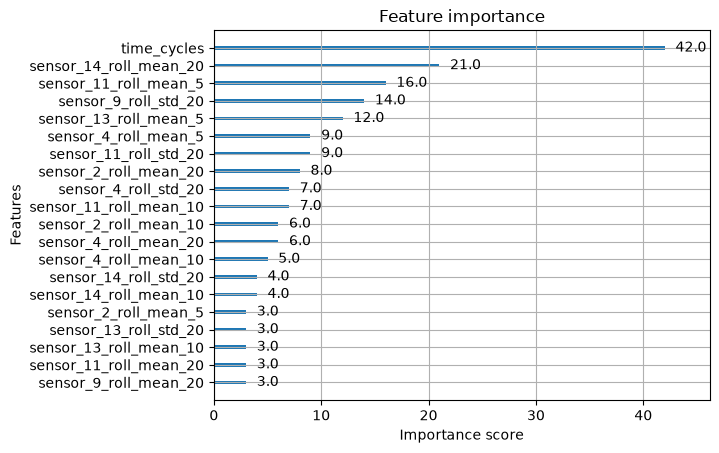

In [37]:
#plot feature importance
xgb.plot_importance(r_XGBR.best_estimator_, max_num_features=20)

Best model

XGB Random Forest Regressor

In [38]:
from xgboost import XGBRFRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score

param_grid = {
    'max_depth': [3, 5, 7, 8, 9],
    'learning_rate': [0.01, 0.1, 0.2, 0.5, 1.0],
    'subsample': [0.4, 0.5, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.8, 1.0],
    'num_parallel_tree':[1, 5, 10],
    
}
group_kfold = GroupKFold(n_splits=5)
xgbr = XGBRFRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgbr_grid = GridSearchCV(
    estimator=xgbr, param_grid=param_grid, cv=group_kfold, n_jobs=-1, verbose=1
)

xgbr_grid.fit(X_train, y_train, groups=train["unit_number"])
print("Best parameters:", xgbr_grid.best_params_)

y_pred = xgbr_grid.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

Fitting 5 folds for each of 1500 candidates, totalling 7500 fits
[17:59:32] INFO: /Users/ec2-user/croot/xgboost-split_1779289786370/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (20631, 17, 350727).
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 1.0, 'max_depth': 7, 'num_parallel_tree': 1, 'subsample': 0.5}
RMSE: 40.673
R²: 0.524


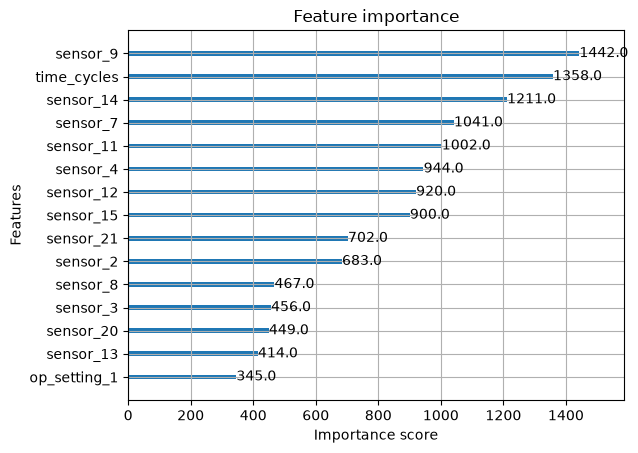

In [39]:
#plot feature importance
from xgboost import plot_importance
best_rf_model = xgbr_grid.best_estimator_
plot_importance(best_rf_model, max_num_features=15)
plt.show()

### LSTM

LSTMs are useful specifically for time series data, because of their ability to remember long term patterns and use sequential patterns to make predictions. The TensorFlow package was used to create the LSTM. Windowing was also done to the data to break the data into the input sequences required for supervised batch training. However, this model performed the best with a window size of 1, which may suggest that the short term information about the data provides most of the information to the model's prediction, and long-term history added no measurable benefit. Repeated trials at window sizes 1 and 2 confirmed this result was consistent rather than due to random variation. This aligns with the previous finding that XGB Regressor performed worse when using data such as the rolling mean or standard deviation or slope for the sensors. The R-squared value was approximately 0.521 and the RMSE value was approximately 40.824. Feature importance was assessed using permutation importance, since LSTMs lack a built-in importance measure like XGBoost's gain-based importance. The most relevant features were sensors 21, 7, 9, 14, and 8. Sensors 7, 9, and 14 have showed up as the most important sensors to previous models' predictive power, however sensors 21 and 8 have not shown up at all. It is possible this is more to do with the method of capturing importance being different for LSTM versus other models. In the future, it may be a good idea to try a combination of another model and LSTM, since on its own, the long term memory is not contributing much to the models predictive power.

In [40]:
def create_sequences(df, feature_cols, target_col, window):
    sequences = []
    targets = []
    for engine_id in df['unit_number'].unique():
        engine_data = df[df['unit_number']==engine_id].reset_index(drop=True)
        if len(engine_data)<window:
            continue
        feature_values=engine_data[feature_cols].values
        target_values= engine_data[target_col].values
        for i in range(len(engine_data) - window + 1):
            seq = feature_values[i : i + window]
            label = target_values[i + window - 1]
            sequences.append(seq)
            targets.append(label)
    return np.array(sequences), np.array(targets)


In [41]:
feature_cols = [c for c in train.columns if c not in ['RUL', 'unit_number']]
feature_cols = [c for c in train.columns 
                 if c not in ['RUL', 'unit_number'] 
                 and 'roll' not in c 
                 and 'slope' not in c
                 and c != 'cycle_pct_of_max_seen']
train[feature_cols] = train[feature_cols].fillna(0)
test[feature_cols] = test[feature_cols].fillna(0)

scaler = StandardScaler() 
train_scaled=train.copy()
train_scaled[feature_cols] = scaler.fit_transform(train[feature_cols])
test_scaled = test.copy()
test_scaled[feature_cols] = scaler.transform(test[feature_cols]) 

X_train_seq, y_train_seq = create_sequences(train_scaled, feature_cols, 'RUL', 2)
X_test_seq, y_test_seq = create_sequences(test_scaled, feature_cols, 'RUL', 2)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print(np.isnan(X_train_seq).sum(), np.isnan(X_test_seq).sum())

X_train_seq shape: (20531, 2, 17)
y_train_seq shape: (20531,)
0 0


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model = Sequential()
lstm_model.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=128))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 2, 17)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,881 (292.50 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)
y_pred = lstm_model.predict(X_test_seq).flatten()

rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
r2 = r2_score(y_test_seq, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

Epoch 1/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8583.6484 - val_loss: 7090.9917
Epoch 2/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2959.8132 - val_loss: 3942.0842
Epoch 3/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1909.1138 - val_loss: 3136.2380
Epoch 4/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1534.1771 - val_loss: 2887.8923
Epoch 5/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1375.1368 - val_loss: 2804.4573
Epoch 6/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1339.0634 - val_loss: 2606.0820
Epoch 7/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1315.5667 - val_loss: 2647.5632
Epoch 8/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1288.7181 - val_loss: 2747.9290
Epoch 9/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1280.8363 - val_loss: 2702.6243
Epoch 10/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1276.7729 - val_loss: 2733.1440
Epoch 11/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1257.71

In [44]:
for window in [1, 2, 3, 4, 5, 6]:
    X_train_seq, y_train_seq = create_sequences(train_scaled, feature_cols, 'RUL', window)
    X_test_seq, y_test_seq = create_sequences(test_scaled, feature_cols, 'RUL', window)
    
    model = Sequential([
        Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        Dropout(0.2),
        LSTM(units=128),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=0)
    
    y_pred = model.predict(X_test_seq).flatten()
    rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
    r2 = r2_score(y_test_seq, y_pred)
    print(f"window={window}: RMSE={rmse:.3f}, R²={r2:.3f}")

410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
window=1: RMSE=40.825, R²=0.521
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
window=2: RMSE=40.455, R²=0.527
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
window=3: RMSE=40.349, R²=0.527
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
window=4: RMSE=40.846, R²=0.512
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
window=5: RMSE=40.561, R²=0.516
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
window=6: RMSE=43.732, R²=0.434


the model gets essentially all its predictive power from the single most recent sensor reading — longer sequences (even just one extra step of history) don't add anything measurable.

In [45]:
for window in [1, 2]:
    for trial in range(3):
        X_train_seq, y_train_seq = create_sequences(train_scaled, feature_cols, 'RUL', window)
        X_test_seq, y_test_seq = create_sequences(test_scaled, feature_cols, 'RUL', window)
        
        lstm_model = Sequential([
            Input(shape=(window, X_train_seq.shape[2])),
            LSTM(units=64),
            Dropout(0.2),
            Dense(1)
        ])
        lstm_model.compile(optimizer='adam', loss='mean_squared_error')
        
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=32,
                  validation_split=0.1, callbacks=[early_stop], verbose=0)
        
        y_pred = model.predict(X_test_seq).flatten()
        r2 = r2_score(y_test_seq, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
        print(f"window={window}, trial={trial}: R²={r2:.3f}")

410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
window=1, trial=0: R²=0.516
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step
window=1, trial=1: R²=0.513
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step
window=1, trial=2: R²=0.515
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step
window=2, trial=0: R²=0.506
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step
window=2, trial=1: R²=0.493
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step
window=2, trial=2: R²=0.480


In [46]:
X_train_seq, y_train_seq = create_sequences(train_scaled, feature_cols, 'RUL', 1)
X_test_seq, y_test_seq = create_sequences(test_scaled, feature_cols, 'RUL', 1)

In [47]:
for units in [32, 64, 96,128]:
    model = Sequential([
            Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
            Dropout(0.2),
            LSTM(units=units),
            Dropout(0.2),
            Dense(1)
        ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model.fit(X_train_seq, y_train_seq, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)
    y_pred = model.predict(X_test_seq).flatten()
    rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
    r2 = r2_score(y_test_seq, y_pred)
    print(f"units={units}: RMSE={rmse:.3f}, R²={r2:.3f}")

410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step
units=32: RMSE=41.044, R²=0.516
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step
units=64: RMSE=40.825, R²=0.521
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step
units=96: RMSE=40.624, R²=0.526
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
units=128: RMSE=40.739, R²=0.523


In [48]:
from tensorflow.keras.optimizers import Adam
for lr in [0.0001, 0.0005, 0.001, 0.005, 0.018]:
    model = Sequential([
            Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
            Dropout(0.2),
            LSTM(units=96),
            Dropout(0.2),
            Dense(1)
        ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model.fit(X_train_seq, y_train_seq, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)
    y_pred = model.predict(X_test_seq).flatten()
    rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
    r2 = r2_score(y_test_seq, y_pred)
    print(f"learning rate={lr}: RMSE={rmse:.3f}, R²={r2:.3f}")

410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step
learning rate=0.0001: RMSE=41.192, R²=0.512
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step
learning rate=0.0005: RMSE=40.819, R²=0.521
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
learning rate=0.001: RMSE=40.759, R²=0.522
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step
learning rate=0.005: RMSE=40.828, R²=0.521
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step
learning rate=0.018: RMSE=41.887, R²=0.496


In [49]:
def permutation_importance_lstm(model, X_test_seq, y_test_seq, feature_cols, n_repeats=3):
    baseline_pred = model.predict(X_test_seq, verbose=0).flatten()
    baseline_r2 = r2_score(y_test_seq, baseline_pred)

    importances = {}
    for i, feature in enumerate(feature_cols):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X_test_seq.copy()
            shuffled_idx = np.random.permutation(X_permuted.shape[0])
            X_permuted[:, :, i] = X_permuted[shuffled_idx, :, i]
            permuted_pred = model.predict(X_permuted, verbose=0).flatten()
            permuted_r2 = r2_score(y_test_seq, permuted_pred)
            drops.append(baseline_r2 - permuted_r2)
        importances[feature] = np.mean(drops)
    return importances



In [50]:
importances = permutation_importance_lstm(lstm_model, X_test_seq, y_test_seq, feature_cols)

#sort and display
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)
for feature, score in sorted_importances:
    print(f"{feature}: {score:.4f}")

sensor_7: 0.0007
sensor_20: 0.0005
sensor_4: 0.0005
sensor_2: 0.0005
sensor_15: 0.0004
sensor_21: 0.0002
sensor_8: 0.0002
sensor_9: 0.0002
sensor_14: 0.0001
op_setting_1: -0.0000
sensor_12: -0.0000
sensor_17: -0.0001
time_cycles: -0.0004
sensor_6: -0.0004
sensor_13: -0.0004
sensor_11: -0.0005
sensor_3: -0.0006


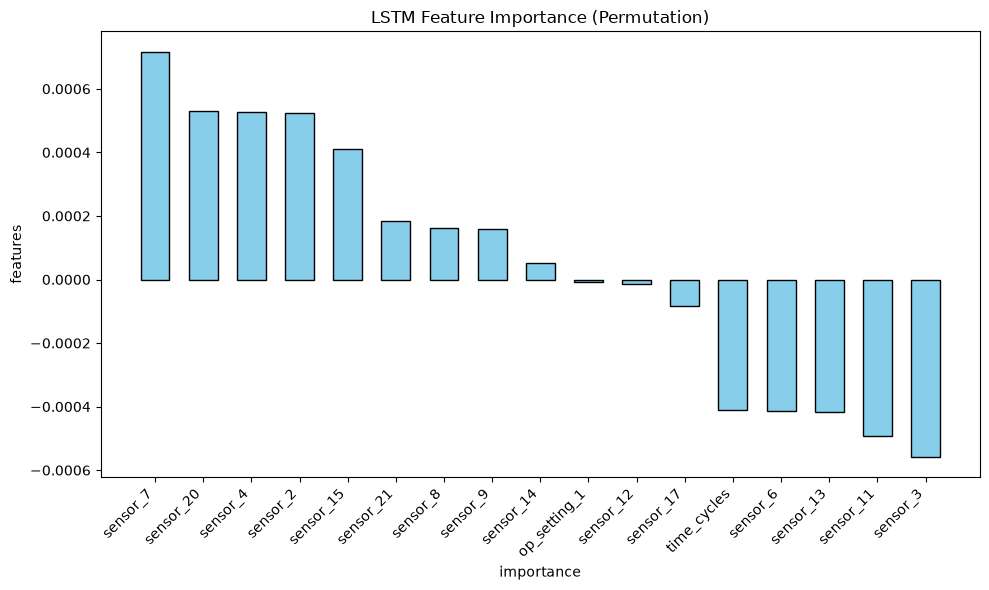

In [51]:
features = [item[0] for item in sorted_importances]
scores = [item[1] for item in sorted_importances]
plt.figure(figsize=(10, 6))
plt.bar(features, scores, color='skyblue', edgecolor='black', width=0.6)
plt.xlabel('importance')
plt.ylabel('features')
plt.title('LSTM Feature Importance (Permutation)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 1D CNN

Convolutional Neural network was used, because of its ability to see complex patterns in the data. Previous models seemed to struggle and seemed to only use information from the short term memory (in the case of XGBoost, no windows was better and slope/rolling mean/Standard deviation did not help) rather than long term. For this reason, a 1D CNN seemed like the logical next step. Only two convolution layers were used, with RELU as the activation function. The model performed better with a lower amount of channels (less overfitting), since CNN Regressors are prone to overfitting (model is prone to memorization since it is trying to predict a continuous number rather than broad categories). The optimizer used was ADAM since it allows for the CNN to converge fast but also more stable. A window size of 30 cycles was used, since the lowest number of total cycles for an engine was 31. When increasing the window size, the R-squared value increased significantly, however this was likely due to data leakage. As window length increased, engines with shorter total lifespans were excluded from evaluation entirely, biasing the test set toward longer-lived (and likely more predictable) engines rather than reflecting genuine model improvement. The best R-squared value (with a window of 30) was approximately 0.518 and the RMSE was approximately 37.900. This model was about on par with both XGBoost Regressor and LSTM. Feature importance was assessed using permutation importance, since CNNs lack a built-in importance measure like XGBoost's gain-based importance. The sensors that contributed the most information to the model's predictive power were 20, 14, 11, 21 and 2. One interesting thing to note is that sensor 20 had a higher importance compared to time cycles. Sensors 14, 11, and 21 all showed up as sensor features providing the most information to the models for LSTM as well, and specifically sensors 14 and 11 consistently showed up as important for all the models. In the future, it may be a good idea to explore combining LSTM or XGBoost Regressor with CNN to test whether different architectures capture complementary aspects of the data that no single model fully exploits.

In [52]:
def create_sequences_with_ids(df, feature_cols, target_col, window):
    sequences = []
    targets = []
    unit_ids = []
    for engine_id in df['unit_number'].unique():
        engine_data = df[df['unit_number']==engine_id].reset_index(drop=True)
        if len(engine_data)<window:
            continue
        feature_values=engine_data[feature_cols].values
        target_values= engine_data[target_col].values
        for i in range(len(engine_data) - window + 1):
            seq = feature_values[i : i + window]
            label = target_values[i + window - 1]
            sequences.append(seq)
            targets.append(label)
            unit_ids.append(engine_id)
    return np.array(sequences), np.array(targets), np.array(unit_ids)

In [53]:
#data preparation
from torch.utils.data import TensorDataset, DataLoader
feature_cols = [c for c in train.columns 
                 if c not in ['RUL', 'unit_number'] 
                 and 'roll' not in c 
                 and 'slope' not in c
                 and c != 'cycle_pct_of_max_seen']
X_train_seq, y_train_seq, unit_ids = create_sequences_with_ids(train_scaled, feature_cols, 'RUL', 30)
X_test_seq, y_test_seq = create_sequences(test_scaled, feature_cols, 'RUL', 30)
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).permute(0, 2, 1)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).permute(0, 2, 1)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(X_train_tensor.shape)
print(X_test_tensor.shape)

torch.Size([17731, 17, 30])
torch.Size([10196, 17, 30])


In [54]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(gss.split(X_train_seq, y_train_seq, groups=unit_ids))

X_train_final = X_train_tensor[train_idx]
X_val_tensor = X_train_tensor[val_idx]
y_train_final = y_train_tensor[train_idx]
y_val_tensor = y_train_tensor[val_idx]

train_dataset = TensorDataset(X_train_final, y_train_final)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(X_train_final.shape)
print(X_val_tensor.shape) 

torch.Size([15847, 17, 30])
torch.Size([1884, 17, 30])


In [55]:
#CNN architecture
class CNNRegressor(nn.Module):
    def __init__(self, num_features, flattened_size):
        super(CNNRegressor, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=32, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

cnn_model = CNNRegressor(num_features=17, flattened_size=384)

In [56]:
#Loss function optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

In [57]:
#Training
import copy
num_epochs=100
patience = 10
best_val_loss = float('inf')
patience_counter=0
for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = cnn_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    cnn_model.eval()
    with torch.no_grad():
        val_predictions = cnn_model(X_val_tensor)
        val_loss = criterion(val_predictions, y_val_tensor).item()
    if val_loss<best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_cnn_model = copy.deepcopy(cnn_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            break
    
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}")
        

print('Finished Training')

Epoch 1/100, Train Loss: 2140.7288, Val Loss: 1023.0292
Epoch 2/100, Train Loss: 1380.8072, Val Loss: 958.6302
Epoch 3/100, Train Loss: 1301.2967, Val Loss: 949.5237
Epoch 4/100, Train Loss: 1220.5988, Val Loss: 909.8425
Epoch 5/100, Train Loss: 1130.6383, Val Loss: 968.3889
Epoch 6/100, Train Loss: 978.8973, Val Loss: 954.2209
Epoch 7/100, Train Loss: 871.7458, Val Loss: 898.7582
Epoch 8/100, Train Loss: 770.7147, Val Loss: 838.7365
Epoch 9/100, Train Loss: 701.9230, Val Loss: 874.8796
Epoch 10/100, Train Loss: 661.5322, Val Loss: 908.9865
Epoch 11/100, Train Loss: 596.0770, Val Loss: 900.3680
Epoch 12/100, Train Loss: 534.2174, Val Loss: 1017.1790
Epoch 13/100, Train Loss: 495.4164, Val Loss: 1192.7271
Epoch 14/100, Train Loss: 454.4343, Val Loss: 1118.9800
Epoch 15/100, Train Loss: 396.8021, Val Loss: 1081.1356
Epoch 16/100, Train Loss: 378.5322, Val Loss: 1151.7784
Epoch 17/100, Train Loss: 359.7107, Val Loss: 1233.5522
Finished Training


In [58]:
#Testing
cnn_model.load_state_dict(best_cnn_model)
cnn_model.eval()

with torch.no_grad(): 
    y_pred_tensor = cnn_model(X_test_tensor)

y_pred = y_pred_tensor.numpy().flatten()
y_true = y_test_tensor.numpy().flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 39.407
R²: 0.479


In [59]:
print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 18/100, Train Loss: 359.7107, Val Loss: 1188.8809


In [60]:
print(f"Final train MSE: {avg_loss:.3f}, sqrt (→RMSE): {np.sqrt(avg_loss):.3f}")
print(f"Final val MSE: {val_loss:.3f}, sqrt (→RMSE): {np.sqrt(val_loss):.3f}")
print(f"Test RMSE (already in RMSE units): {rmse:.3f}")

Final train MSE: 359.711, sqrt (→RMSE): 18.966
Final val MSE: 1188.881, sqrt (→RMSE): 34.480
Test RMSE (already in RMSE units): 39.407


In [61]:
for window in [10, 15, 20, 25, 30]:
    X_train_seq, y_train_seq, unit_ids = create_sequences_with_ids(train_scaled, feature_cols, 'RUL', window)
    X_test_seq, y_test_seq = create_sequences(test_scaled, feature_cols, 'RUL', window)
    X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).permute(0, 2, 1)
    y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).permute(0, 2, 1)
    y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).unsqueeze(1)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, val_idx = next(gss.split(X_train_seq, y_train_seq, groups=unit_ids))

    X_train_final = X_train_tensor[train_idx]
    X_val_tensor = X_train_tensor[val_idx]
    y_train_final = y_train_tensor[train_idx]
    y_val_tensor = y_train_tensor[val_idx]

    train_dataset = TensorDataset(X_train_final, y_train_final)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


    with torch.no_grad():
        dummy = torch.zeros(1, X_train_tensor.shape[1], X_train_tensor.shape[2])
        conv1 = nn.Conv1d(X_train_tensor.shape[1], 32, kernel_size=3)
        pool1 = nn.MaxPool1d(kernel_size=2)
        conv2 = nn.Conv1d(32, 64, kernel_size=3)
        pool2 = nn.MaxPool1d(kernel_size=2)
        out = pool2(conv2(pool1(conv1(dummy))))
        flattened_size = out.shape[1] * out.shape[2]

    cnn_model = CNNRegressor(num_features=X_train_tensor.shape[1], flattened_size=flattened_size)
    optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = nn.MSELoss()

    num_epochs=100
    patience = 10
    best_val_loss = float('inf')
    patience_counter=0
    for epoch in range(num_epochs):
        cnn_model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = cnn_model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        cnn_model.eval()
        with torch.no_grad():
            val_predictions = cnn_model(X_val_tensor)
            val_loss = criterion(val_predictions, y_val_tensor).item()
        if val_loss<best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_cnn_model = copy.deepcopy(cnn_model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
        
        avg_loss = running_loss / len(train_loader)
            

    print('Finished Training')

    cnn_model.load_state_dict(best_cnn_model)
    cnn_model.eval()

    with torch.no_grad(): 
        y_pred_tensor = cnn_model(X_test_tensor)

    y_pred = y_pred_tensor.numpy().flatten()
    y_true = y_test_tensor.numpy().flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f'Window: {window}, RMSE: {rmse:.3f}, R²: {r2:.3f}, final train (→RMSE): {np.sqrt(avg_loss):.3f}, final eval (→RMSE): {np.sqrt(val_loss):.3f}')

Finished Training
Window: 10, RMSE: 39.930, R²: 0.518, final train (→RMSE): 33.816, final eval (→RMSE): 33.909
Finished Training
Window: 15, RMSE: 40.111, R²: 0.500, final train (→RMSE): 31.211, final eval (→RMSE): 34.171
Finished Training
Window: 20, RMSE: 40.953, R²: 0.465, final train (→RMSE): 24.402, final eval (→RMSE): 33.552
Finished Training
Window: 25, RMSE: 42.037, R²: 0.421, final train (→RMSE): 20.253, final eval (→RMSE): 36.216
Finished Training
Window: 30, RMSE: 37.207, R²: 0.535, final train (→RMSE): 21.527, final eval (→RMSE): 31.818


In [62]:
print(X_test_seq.shape[0])  # how many test sequences actually exist at window=150?
print(test.groupby('unit_number').size().describe())  # compare to unit length distribution

10196
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
dtype: float64


In [63]:
def permutation_importance_cnn(model, X_test_tensor, y_test_tensor, feature_cols, n_repeats=3):
    with torch.no_grad():
        baseline_pred = model(X_test_tensor).numpy().flatten()
    baseline_r2 = r2_score(y_test_tensor, baseline_pred)

    importances = {}
    for i, feature in enumerate(feature_cols):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X_test_tensor.clone()
            shuffled_idx = np.random.permutation(X_permuted.shape[0])
            X_permuted[:, i, :] = X_permuted[shuffled_idx, i, :]
            with torch.no_grad():
                permuted_pred = model(X_permuted).numpy().flatten()
            permuted_r2 = r2_score(y_test_tensor, permuted_pred)
            drops.append(baseline_r2 - permuted_r2)
        importances[feature] = np.mean(drops)
    return importances

In [64]:
importances = permutation_importance_cnn(cnn_model, X_test_tensor, y_test_tensor, feature_cols)

#sort and display
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)
for feature, score in sorted_importances:
    print(f"{feature}: {score:.4f}")

sensor_20: 0.2362
sensor_14: 0.1655
sensor_11: 0.1468
time_cycles: 0.0972
sensor_21: 0.0639
sensor_7: 0.0603
sensor_4: 0.0512
sensor_8: 0.0423
sensor_2: 0.0356
sensor_13: 0.0327
sensor_12: 0.0248
sensor_15: 0.0184
sensor_17: 0.0133
sensor_9: 0.0079
sensor_3: 0.0073
sensor_6: 0.0014
op_setting_1: -0.0033


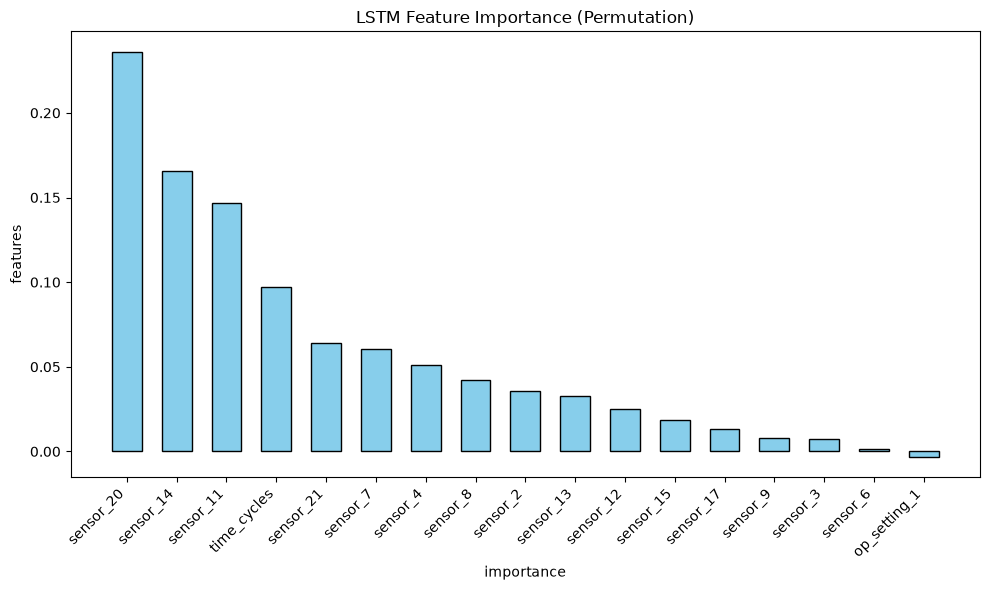

In [65]:
features = [item[0] for item in sorted_importances]
scores = [item[1] for item in sorted_importances]
plt.figure(figsize=(10, 6))
plt.bar(features, scores, color='skyblue', edgecolor='black', width=0.6)
plt.xlabel('importance')
plt.ylabel('features')
plt.title('LSTM Feature Importance (Permutation)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Results
For the most part, it seems that the models were unable to achieve an R-squared value higher than around 0.52. The R-squared values are as follows: ~0.47 (multiple linear regression), ~0.52 (default random forest), ~0.523 (XGB Regressor), ~0.524 (XGB Random Forest), ~0.521 (LSTM), ~0.518 (CNN).The sensors that tended to provide the most information towards the model's predictive power seemed to have always been sensor 14. Sensor 14 is likely capturing a genuine and robust degradation signal and in the future it is worth exploring what this sensor is and how it can be manipulated further. There were also many sensors that showed up for multiple models but not all of them. For example sensors 9 and 7 showed up for XGB Regressor, XGB random forest, LSTM. Sensors 7 and 11 showed up for XGB Regressor, XGB random forest, and default random forest. This may be the result of metrics: LSTM and CNN used permutation importance, while the XGBoost and Random Forest models used gain-based (tree-based) importance—these methods are not directly comparable in magnitude or mechanism, and some inconsistency may simply reflect this difference. It is also possible that this may be the result of different models weighing or biasing features differently. A correlation analysis revealed two distinct sensor relationships among the top-ranked features. Sensors 9 and 14 were extremely highly correlated (r=0.96), indicating these two sensors capture nearly the same underlying degradation signal—this likely explains why different models identified one or the other as most important, since the two are largely interchangeable from a predictive standpoint. Separately, sensors 7 and 11 showed a strong negative correlation (r=-0.82), suggesting a tight but inverse relationship that could similarly allow either sensor to serve as a substitute for the other. Interestingly, these two pairs were only weakly related to each other (correlations ranging from -0.22 to 0.16). This indicates that within the pairs, the sensors are interchangeable, but between them, they contribute significantly different information. This suggests that these sensors aren't a completely redundant cluster; there is meaningful redundancy within the pairs, but the two pairs themselves capture non-overlapping aspects of the engine degredation.

# Conclusion
All the models seemed to converge to a ceiling with R-squared values ranging narrowly between approximately 0.47 and 0.524. It seems that the features time cycle and sensor 14 captures most of the predictive signal for this task and temporal feature engineering (slope, rolling mean, standard deviation etc.) and longer sequence history did not meaningfully increase the model's predictive power. Some sensors showed up repeatedly such as sensors 9 and 7 for LSTM and XGB Regressor and XGB Random Forest as well as sensor ll for XGB Regressor and XGB Random Forest with default Random Forest, however this may be due to differences in measuring importance between models. Seeing as what the actual sensors correspond to is not given in this dataset, a future endeavor may be to find out the sort of sensor data given and see if further feature engineering can be done (or further processing depending on the type of sensor). Another task could be to try and combine multiple models. For example LSTM has the ability to use long term information and short term information to make predictions, and this model may perform better if it is combined with CNN's ability to understand patterns and make predictions based on that. 